<a href="https://colab.research.google.com/github/tr33yut/-Netflix-/blob/main/%E0%B9%8CNetflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
import matplotlib.font_manager as fm

# ดาวน์โหลดฟอนต์ TH Sarabun New มาไว้ในเครื่อง
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf -O thsarabunnew-webfont.ttf

# บังคับเพิ่มฟอนต์เข้า Matplotlib
fm.fontManager.addfont('thsarabunnew-webfont.ttf')

# ตั้งค่าให้กราฟทั้งหมดใช้ฟอนต์นี้เป็นค่าเริ่มต้น
plt.rcParams['font.family'] = 'TH Sarabun New'

In [17]:
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/MyDrive/netflix/Movie_Netfilx 1.xlsx"
OUT_DIR = "."

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.family"] = "TH Sarabun New"
plt.rcParams["axes.unicode_minus"] = False

SEG_COLORS = {"Films (English)": "#AEC6CF", "Films (Non-English)": "#FFDAC1"}

In [18]:
df = pd.read_excel(DATA_PATH)
df = df[df["best_rank"] == 1].copy()  # เฉพาะเรื่องที่เคยขึ้นอันดับ 1
df = df.rename(columns={"ขาดทุน": "profit_loss_usd"})
df["is_flop"] = df["profit_loss_usd"] < 0
df["roi_pct"] = df["profit_loss_usd"] / df["Budget_USD"] * 100

segments = ["Films (English)", "Films (Non-English)"]
seg_df = {s: df[df["category"] == s].copy() for s in segments}

In [19]:
##df = df[df["show_title"] != "KPop Demon Hunters"]

In [20]:
df.head(3)

,show_title,category,best_rank,total_hours_viewed,total_views,total_weeks_in_top10,runtime,Budget_USD,Box_Office_USD,profit_loss_usd,imdb_id,imdb_rating,imdb_total_votes,genres,is_flop,roi_pct
19,A Man Called Otto,Films (English),1,66450000,8.591667e+06,6,2.10,50000000,113360085,63360085,tt7405458,7.5,215754.0,Comedy,False,126.720170
35,All Quiet on the Western Front,Films (Non-English),1,176490000,1.200612e+06,23,147.00,1448864,3270000,1821136,tt1016150,7.8,345909.0,War,False,125.694061
47,Anaconda,Films (English),1,45400000,2.750000e+07,4,1.65,45000000,135148320,90148320,tt33244668,5.5,73285.0,Adventure,False,200.329600


In [21]:
print(f"เฉพาะ best_rank == 1: {len(df)} เรื่อง")
for s in segments:
    d = seg_df[s]
    print(f"  {s}: {len(d)} เรื่อง | เจ๊ง {d['is_flop'].sum()} เรื่อง ({d['is_flop'].mean():.1%})")

เฉพาะ best_rank == 1: 56 เรื่อง
  Films (English): 30 เรื่อง | เจ๊ง 11 เรื่อง (36.7%)
  Films (Non-English): 26 เรื่อง | เจ๊ง 8 เรื่อง (30.8%)


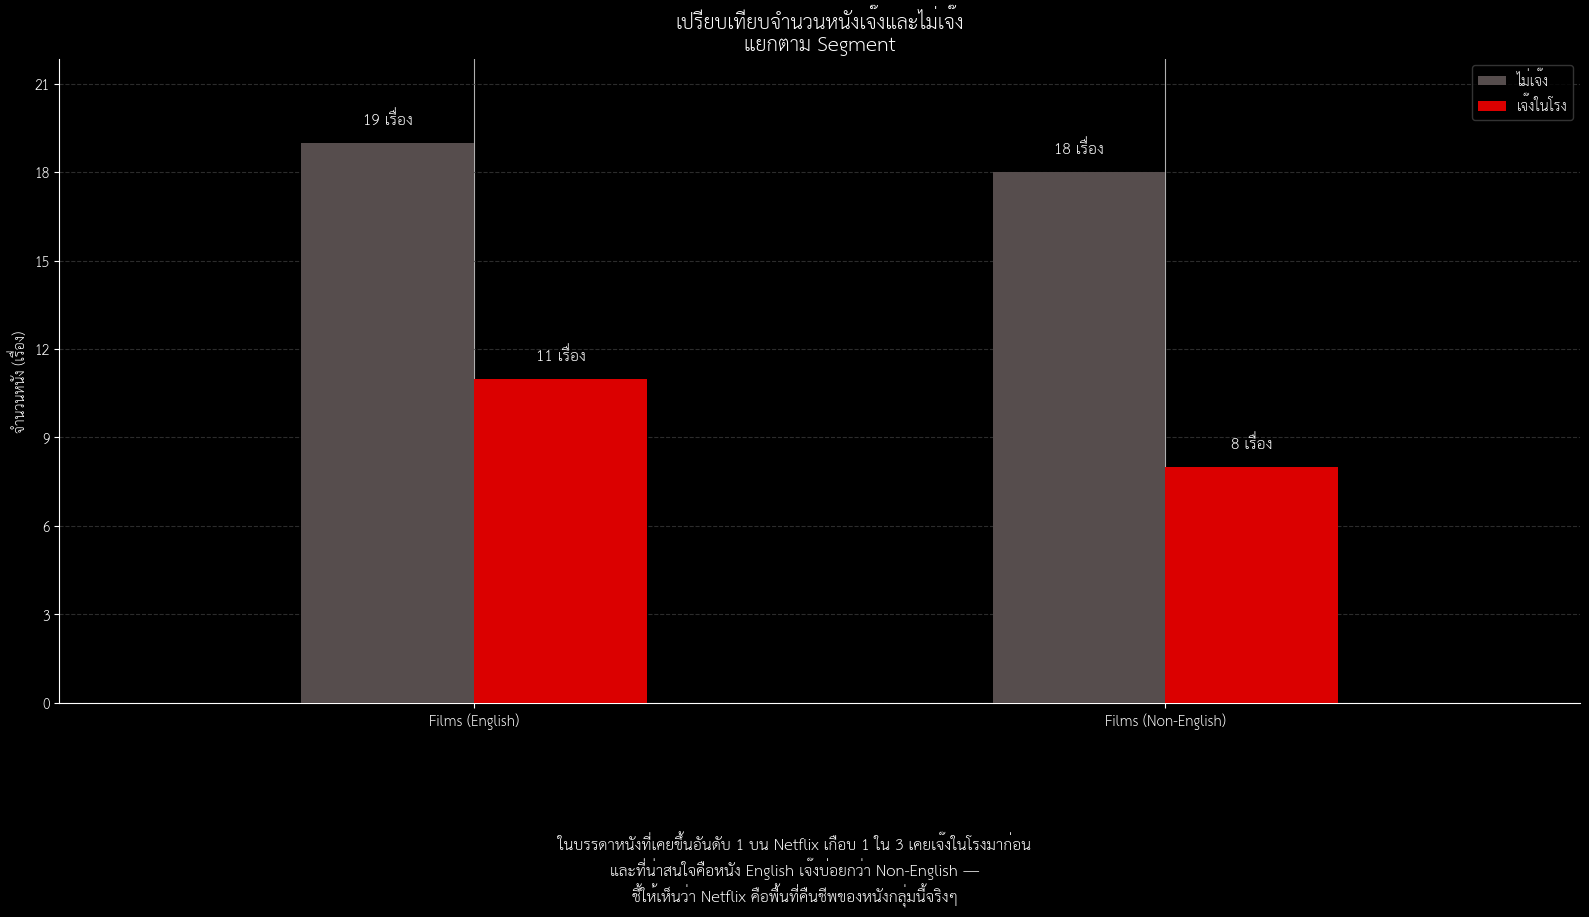

In [22]:
import numpy as np
from matplotlib.ticker import MaxNLocator

# สมมติว่า segments เรียงลำดับเป็น ['English', 'Non-English']
labels = segments

# คำนวณจำนวนหนังเจ๊ง และ ไม่เจ๊ง
flop_counts = [seg_df[s]["is_flop"].sum() for s in segments]
totals = [len(seg_df[s]) for s in segments]
not_flop_counts = [t - f for t, f in zip(totals, flop_counts)]

caption_text = ("ในบรรดาหนังที่เคยขึ้นอันดับ 1 บน Netflix เกือบ 1 ใน 3 เคยเจ๊งในโรงมาก่อน\n"
                "และที่น่าสนใจคือหนัง English เจ๊งบ่อยกว่า Non-English —\n"
                "ชี้ให้เห็นว่า Netflix คือพื้นที่คืนชีพของหนังกลุ่มนี้จริงๆ")

# กำหนดตำแหน่ง x สำหรับ 2 กลุ่ม
x = np.arange(len(labels))
width = 0.25

# ปรับขนาดภาพเป็น (16, 7.5) เพื่อให้เท่ากันทุกกราฟ
fig, ax = plt.subplots(figsize=(16, 7.5))

# ตั้งค่าสีพื้นหลังเป็นสีดำ #000000
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')

# 1. สร้างแท่งกราฟ (เอา "ไม่เจ๊ง" ไว้ด้านซ้าย และ "เจ๊ง" ไว้ด้านขวา)
bars_not_flop = ax.bar(x - width/2, not_flop_counts, width, label='ไม่เจ๊ง', color='#564d4d', zorder=3)
bars_flop = ax.bar(x + width/2, flop_counts, width, label='เจ๊งในโรง', color='#db0000', zorder=3)

# 2. เพิ่มเส้นกริดด้านใน โดยตั้ง alpha=0.7 เพื่อให้จางลง 30%
ax.grid(axis='y', linestyle='--', color='#404040', zorder=0, alpha=0.7)

# ตัวแปรสีสำหรับตัวหนังสือ
text_color = "#ffffff"

# ฟังก์ชันสำหรับใส่ตัวเลขกำกับบนแท่งกราฟ
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
                f"{int(height)} เรื่อง",
                ha="center", va="bottom", fontsize=11, color=text_color)

# เรียกใช้ฟังก์ชันเติมตัวเลข (เรียงตามลำดับแท่งซ้ายไปขวา)
add_labels(bars_not_flop)
add_labels(bars_flop)

# 3. บังคับให้สเกลแกน Y แสดงเฉพาะตัวเลขจำนวนเต็ม
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# ตั้งค่า Label, Title และ X-ticks
ax.set_ylabel("จำนวนหนัง (เรื่อง)", color=text_color)
ax.set_ylim(0, max(max(flop_counts), max(not_flop_counts)) * 1.15)
ax.set_title("เปรียบเทียบจำนวนหนังเจ๊งและไม่เจ๊ง\nแยกตาม Segment", fontsize=14, color=text_color)
ax.set_xticks(x)
ax.set_xticklabels(labels, color=text_color)

# กำหนดขอบเขตแกน X
ax.set_xlim(-0.6, len(labels) - 0.4)

# ปิดกรอบด้านบนและขวา
ax.spines[["top", "right"]].set_visible(False)

# ตั้งค่าสีเส้นขอบกราฟ (Spines) และตัวเลขบนแกนให้เป็นสีขาว
ax.spines["bottom"].set_color(text_color)
ax.spines["left"].set_color(text_color)
ax.tick_params(colors=text_color)

# เพิ่ม Legend
ax.legend(facecolor='#000000', edgecolor='#404040', labelcolor=text_color, loc='upper right')

# ตั้งค่า Caption ด้านล่างกราฟ
fig.text(0.5, -0.12, caption_text,
         ha="center", va="top", wrap=True,
         fontsize=11, color=text_color)

fig.tight_layout()

# กำหนด facecolor ตอนเซฟรูป
fig.savefig(f"{OUT_DIR}/flop_count_grouped_by_segment.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)


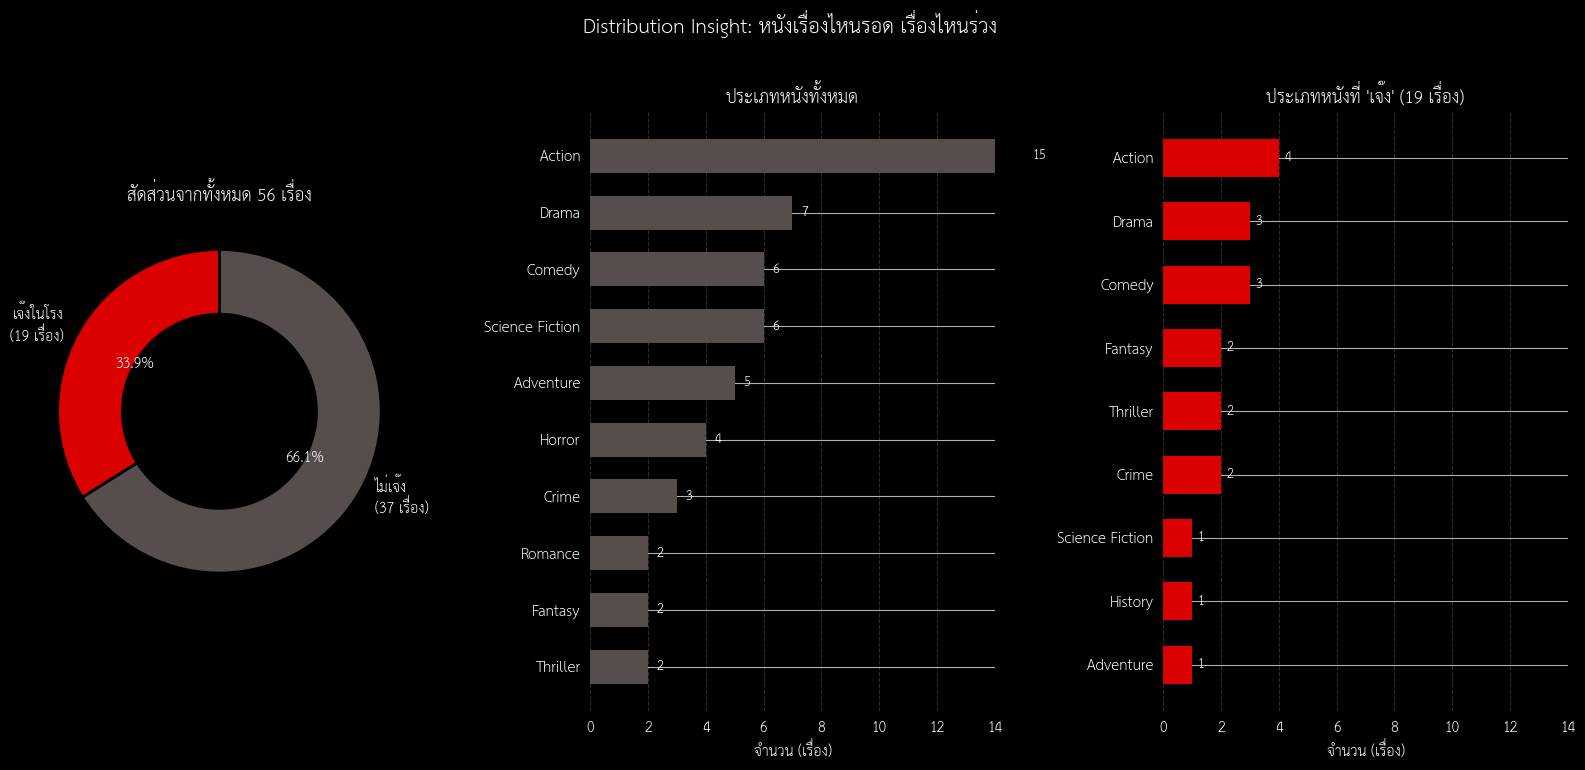

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

gen_col = "genres"
total_movies = len(df)
flop_total = df["is_flop"].sum()
not_flop_total = total_movies - flop_total

genre_all = df[gen_col].value_counts().head(10)
genre_flops = df[df["is_flop" ] == True][gen_col].value_counts().head(10)

# ปรับขนาดภาพเป็น (16, 7.5) ให้เท่ากันกับกราฟอื่น ๆ
fig, axes = plt.subplots(1, 3, figsize=(16, 7.5))
fig.patch.set_facecolor('#000000')
text_color = "#ffffff"

ax1 = axes[0]
ax1.set_facecolor('#000000')
pie_labels = [f'เจ๊งในโรง\n({flop_total} เรื่อง)', f'ไม่เจ๊ง\n({not_flop_total} เรื่อง)']
pie_sizes = [flop_total, not_flop_total]
pie_colors = ['#db0000', '#564d4d']

wedges, texts, autotexts = ax1.pie(pie_sizes, labels=pie_labels, colors=pie_colors,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops=dict(color=text_color, fontsize=10, fontweight='bold'),
                                   wedgeprops=dict(width=0.4, edgecolor='#000000', linewidth=2))
ax1.set_title(f"สัดส่วนจากทั้งหมด {total_movies} เรื่อง", color=text_color, fontsize=12)

ax2 = axes[1]
ax2.set_facecolor('#000000')
ax2.grid(axis='x', linestyle='--', color='#404040', zorder=0, alpha=0.7)
bars2 = ax2.barh(genre_all.index[::-1], genre_all.values[::-1], color='#564d4d', height=0.6, zorder=3)
ax2.set_title("ประเภทหนังทั้งหมด", color=text_color, fontsize=12)
ax2.set_xlabel("จำนวน (เรื่อง)", color=text_color)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.set_xlim(right=14) # Adjust x-axis scale to 14

for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             ha='left', va='center', color=text_color, fontsize=9)

ax3 = axes[2]
ax3.set_facecolor('#000000')
ax3.grid(axis='x', linestyle='--', color='#404040', zorder=0, alpha=0.7)
bars3 = ax3.barh(genre_flops.index[::-1], genre_flops.values[::-1], color='#db0000', height=0.6, zorder=3)
ax3.set_title(f"ประเภทหนังที่ 'เจ๊ง' ({flop_total} เรื่อง)", color=text_color, fontsize=12)
ax3.set_xlabel("จำนวน (เรื่อง)", color=text_color)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
ax3.set_xlim(right=14) # Adjust x-axis scale to 14

for bar in bars3:
    width = bar.get_width()
    ax3.text(width + 0.2, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             ha='left', va='center', color=text_color, fontsize=9)

for ax in [ax2, ax3]:
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    ax.tick_params(colors=text_color, left=False, bottom=False)

fig.suptitle("Distribution Insight: หนังเรื่องไหนรอด เรื่องไหนร่วง", color=text_color, fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/genre_distribution_flops.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)



--- สถิติกำไร/ขาดทุน แยกตาม segment ---
                     count         mean          min          max
category                                                         
Films (English)       30.0  101032387.0 -206000000.0  954800131.0
Films (Non-English)   26.0   58405193.0  -65498719.0  619000000.0

Correlation ต่อ segment:
                     corr_budget_boxoffice  corr_budget_loss
Films (English)                      0.189            -0.022
Films (Non-English)                  0.763             0.548


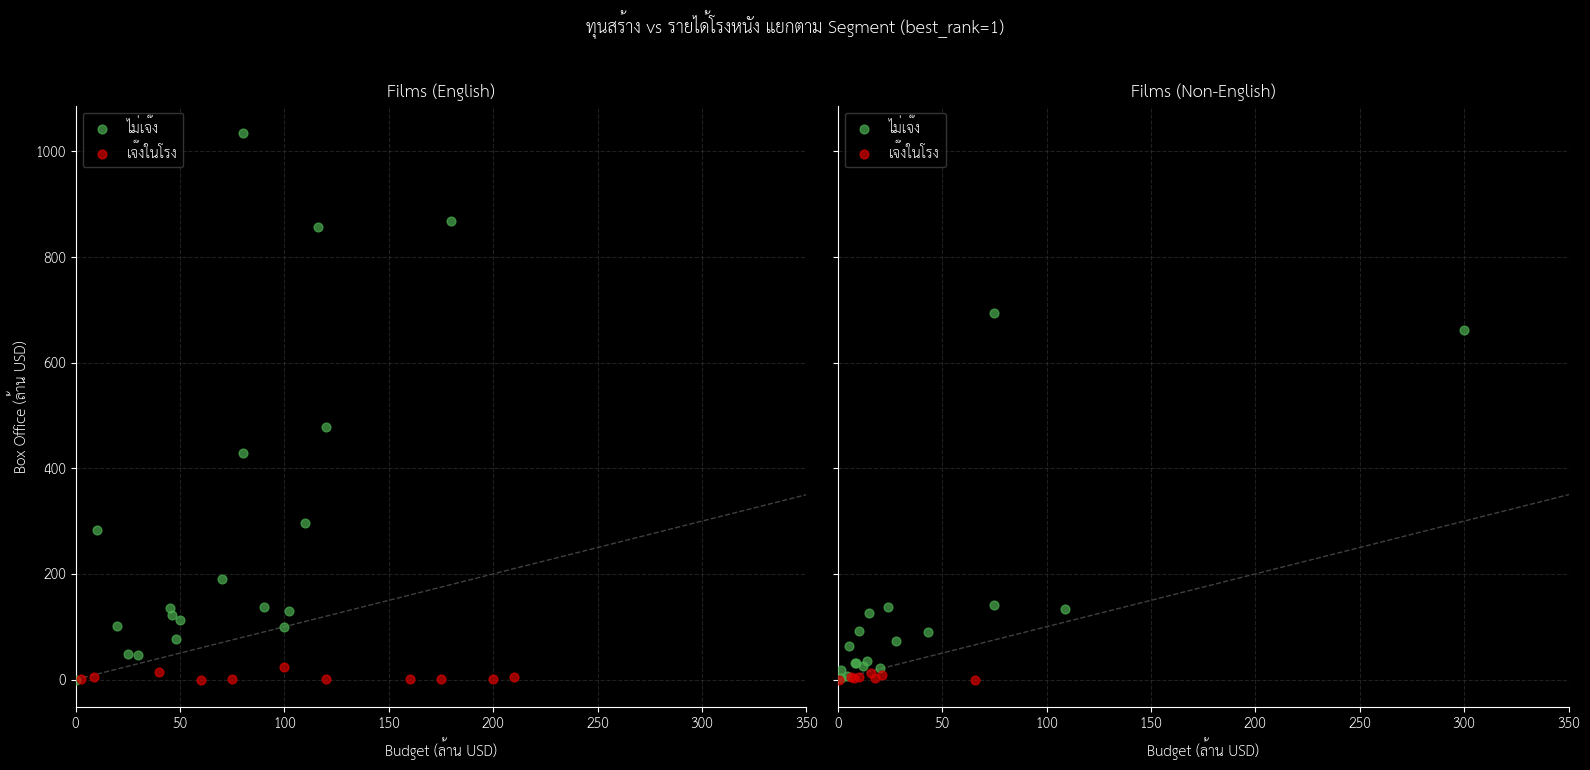

<Figure size 900x500 with 0 Axes>

In [24]:
print("\n--- สถิติกำไร/ขาดทุน แยกตาม segment ---")
summary1 = df.groupby("category")["profit_loss_usd"].describe()[["count", "mean", "min", "max"]]
print(summary1.round(0))

corr_tbl = {}
for s in segments:
    d = seg_df[s]
    corr_tbl[s] = {
        "corr_budget_boxoffice": d["Budget_USD"].corr(d["Box_Office_USD"]),
        "corr_budget_loss": d["Budget_USD"].corr(d["profit_loss_usd"]),
    }
print("\nCorrelation ต่อ segment:")
print(pd.DataFrame(corr_tbl).T.round(3))

# ปรับขนาดภาพเป็น (16, 7.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True)
fig.patch.set_facecolor('#000000')
text_color = "#ffffff"
line_color = "#404040"

for ax, s in zip(axes, segments):
    ax.set_facecolor('#000000')
    d = seg_df[s]

    # แยกข้อมูลเป็น 2 กลุ่ม เพื่อให้ใส่ Label สำหรับทำ Legend ได้ง่าย
    d_non_flop = d[~d["is_flop"]]
    d_flop = d[d["is_flop"]]

    # พล็อตจุดหนังที่ไม่เจ๊ง (สีเขียว)
    ax.scatter(d_non_flop["Budget_USD"] / 1e6, d_non_flop["Box_Office_USD"] / 1e6,
               c="#4caf50", alpha=0.7, s=40, zorder=3, label="ไม่เจ๊ง")

    # พล็อตจุดหนังที่เจ๊ง (สีแดง)
    ax.scatter(d_flop["Budget_USD"] / 1e6, d_flop["Box_Office_USD"] / 1e6,
               c="#db0000", alpha=0.7, s=40, zorder=3, label="เจ๊งในโรง")

    max_y = d["Box_Office_USD"].max() / 1e6
    lims = [0, max(350, max_y)]
    ax.plot(lims, lims, color=line_color, linestyle="--", linewidth=1, zorder=2)
    ax.set_xlim(0, 350)
    ax.grid(color=line_color, linestyle='--', zorder=0, alpha=0.5)

    ax.set_title(s, color=text_color)
    ax.set_xlabel("Budget (ล้าน USD)", color=text_color)

    ax.spines["bottom"].set_color(text_color)
    ax.spines["left"].set_color(text_color)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=text_color)

    # เพิ่ม Legend ในแต่ละ Subplot ให้เข้ากับ Dark Theme
    ax.legend(facecolor='#000000', edgecolor=line_color, labelcolor=text_color, loc='upper left')

axes[0].set_ylabel("Box Office (ล้าน USD)", color=text_color)
fig.suptitle("ทุนสร้าง vs รายได้โรงหนัง แยกตาม Segment (best_rank=1)", color=text_color, y=1.02)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/act1_budget_vs_boxoffice_by_segment.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)
plt.savefig('filename.png', bbox_inches='tight', dpi=300)



---Box Office vs Total Views (เฉพาะกลุ่มเจ๊ง) ---


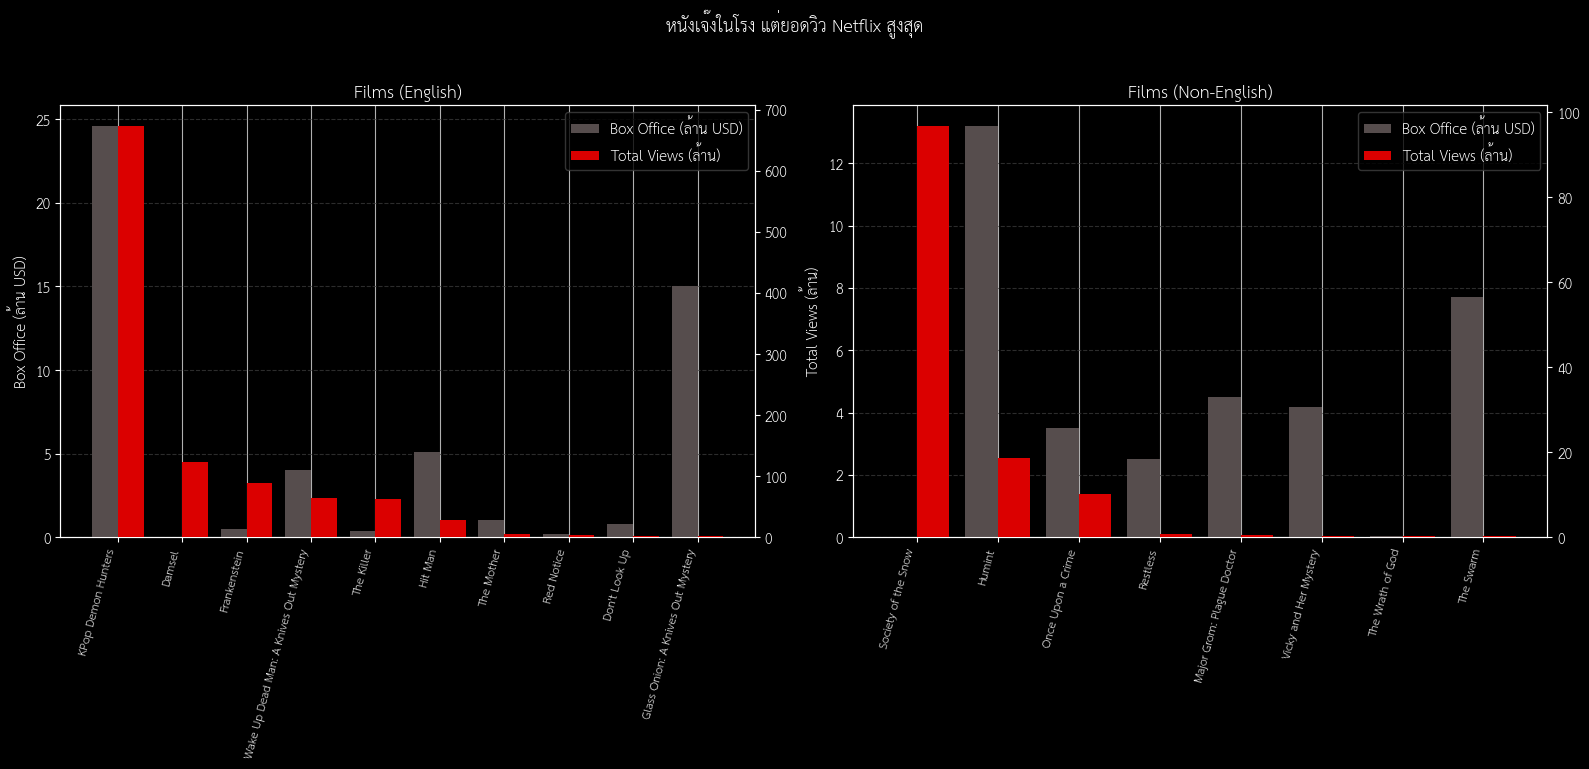


--- ทุนสร้างซื้อความยั่งยืนบนชาร์ตได้ไหม? ---


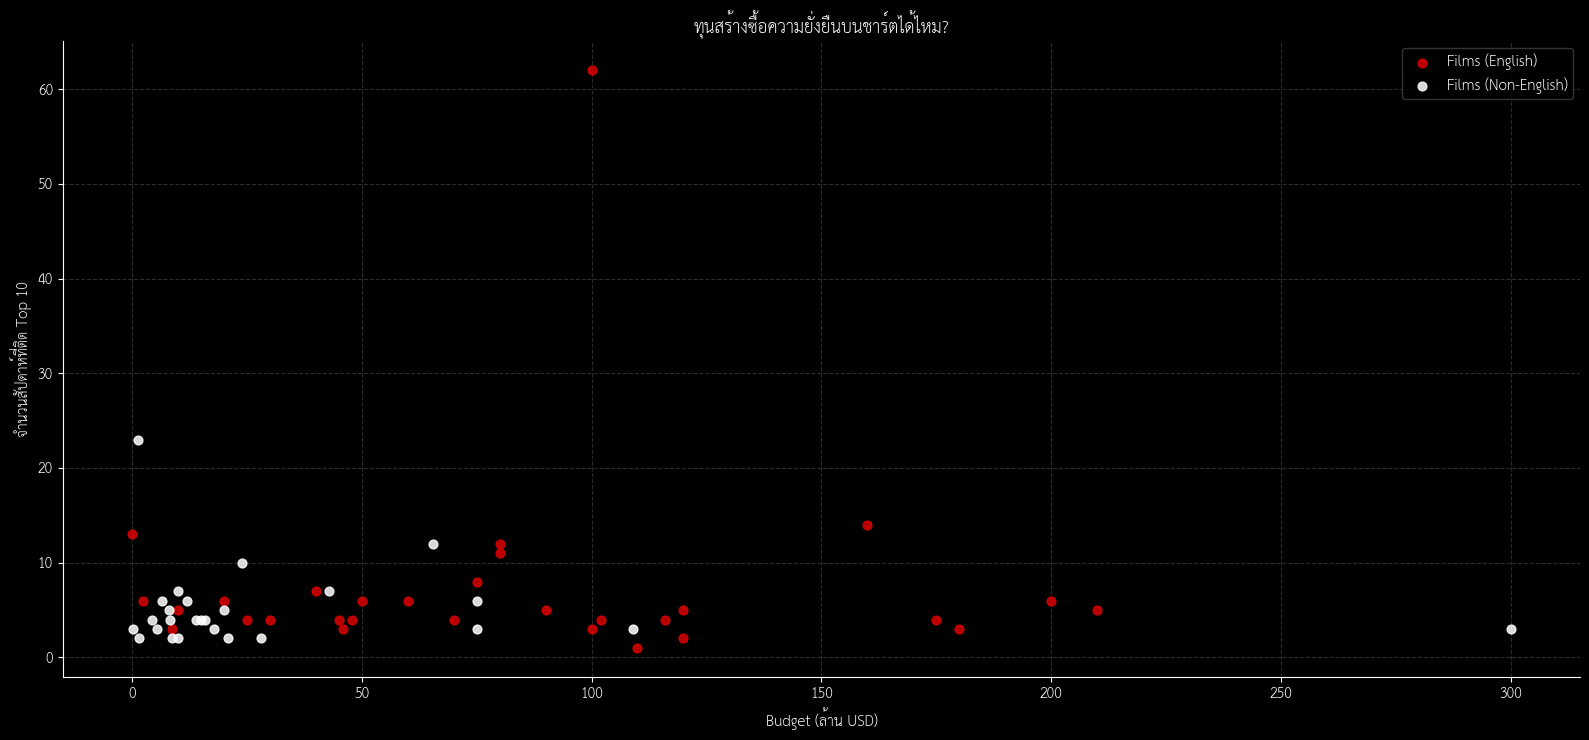

In [25]:
print("\n---Box Office vs Total Views (เฉพาะกลุ่มเจ๊ง) ---")
# ปรับขนาดภาพเป็น (16, 7.5) ให้เท่ากันกับกราฟอื่น ๆ
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
fig.patch.set_facecolor('#000000')
text_color = "#ffffff"
line_color = "#404040"
color_box_office = "#564d4d"
color_views = "#db0000"

for ax, s in zip(axes, segments):
    ax.set_facecolor('#000000')
    d = seg_df[s]
    flops = d[d["is_flop"]].sort_values("total_views", ascending=False).head(10)
    x = np.arange(len(flops))

    bars1 = ax.bar(x - 0.2, flops["Box_Office_USD"] / 1e6, width=0.4,
                   label="Box Office (ล้าน USD)", color=color_box_office, zorder=3)

    ax2 = ax.twinx()
    bars2 = ax2.bar(x + 0.2, flops["total_views"] / 1e6, width=0.4,
                    label="Total Views (ล้าน)", color=color_views, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(flops["show_title"], rotation=75, ha="right", fontsize=8, color=text_color)
    ax.set_title(s, color=text_color)
    ax.grid(axis='y', color=line_color, linestyle='--', zorder=0, alpha=0.7)
    ax2.grid(False)

    for spine in ax.spines.values():
        spine.set_color(text_color)
    for spine in ax2.spines.values():
        spine.set_color(text_color)

    ax.tick_params(colors=text_color)
    ax2.tick_params(colors=text_color)

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2,
               facecolor='#000000', edgecolor=line_color, labelcolor=text_color, loc='upper right')

axes[0].set_ylabel("Box Office (ล้าน USD)", color=text_color)
axes[1].set_ylabel("Total Views (ล้าน)", color=text_color)
fig.suptitle("หนังเจ๊งในโรง แต่ยอดวิว Netflix สูงสุด", color=text_color, y=1.02)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/act2_boxoffice_vs_views_by_segment.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)

print("\n--- ทุนสร้างซื้อความยั่งยืนบนชาร์ตได้ไหม? ---")
# ปรับขนาดภาพเป็น (16, 7.5) ให้เท่ากันกับกราฟอื่น ๆ
fig, ax = plt.subplots(figsize=(16, 7.5))
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')
scatter_colors = ["#db0000", "#ffffff"]

for i, s in enumerate(segments):
    d = seg_df[s]
    c = scatter_colors[i % len(scatter_colors)]
    ax.scatter(d["Budget_USD"] / 1e6, d["total_weeks_in_top10"],
               label=s, color=c, alpha=0.85, s=40, zorder=3)

ax.set_xlabel("Budget (ล้าน USD)", color=text_color)
ax.set_ylabel("จำนวนสัปดาห์ที่ติด Top 10", color=text_color)
ax.set_title("ทุนสร้างซื้อความยั่งยืนบนชาร์ตได้ไหม?", color=text_color)
ax.grid(color=line_color, linestyle='--', zorder=0, alpha=0.7)
ax.spines["bottom"].set_color(text_color)
ax.spines["left"].set_color(text_color)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors=text_color)
ax.legend(facecolor='#000000', edgecolor=line_color, labelcolor=text_color)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/act2_budget_vs_weeks_by_segment.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)



--- Box Office vs Total Views (เฉพาะกลุ่มเจ๊ง) ---


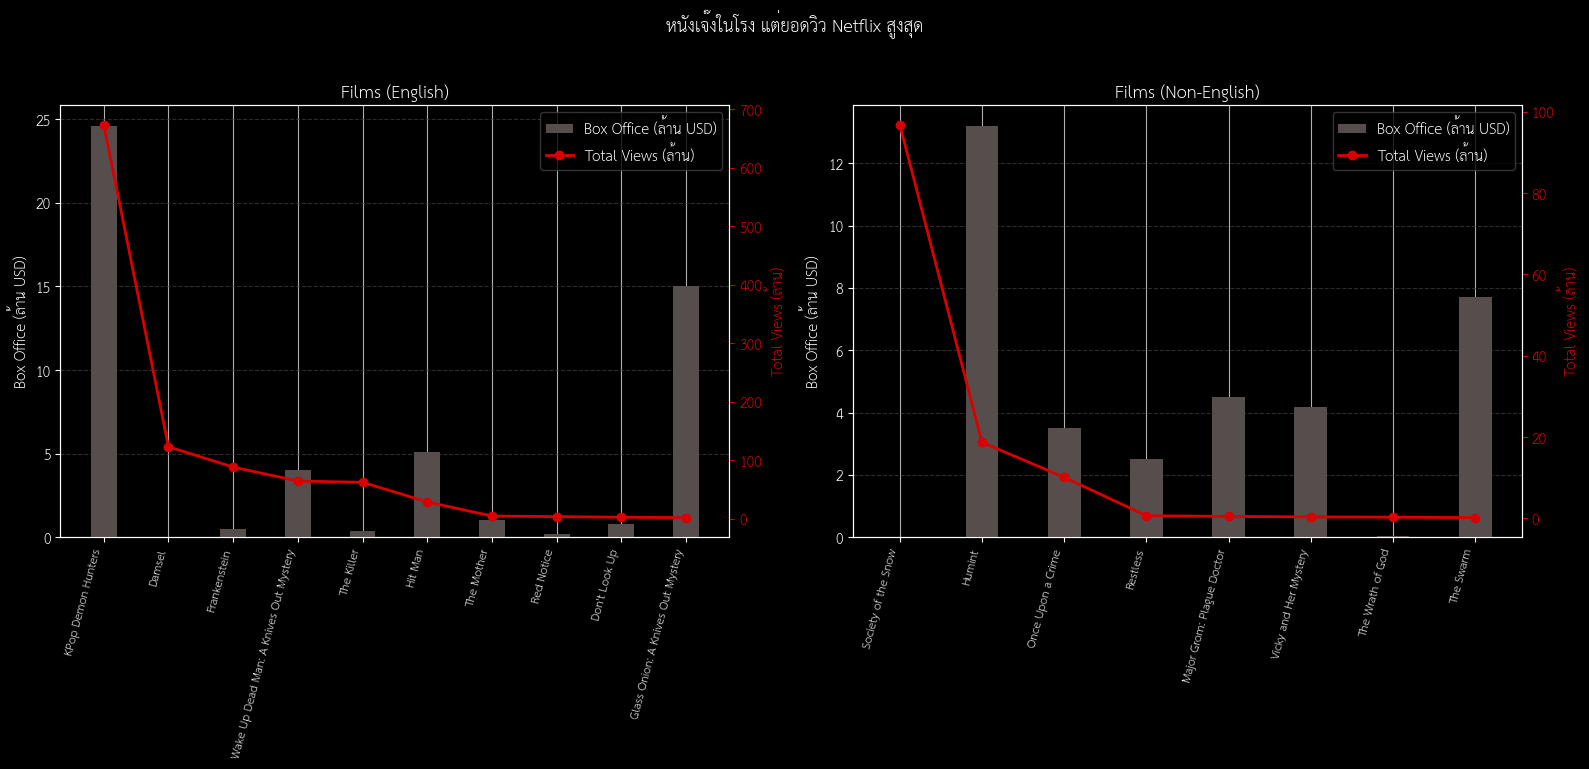


--- ทุนสร้างซื้อความยั่งยืนบนชาร์ตได้ไหม? ---


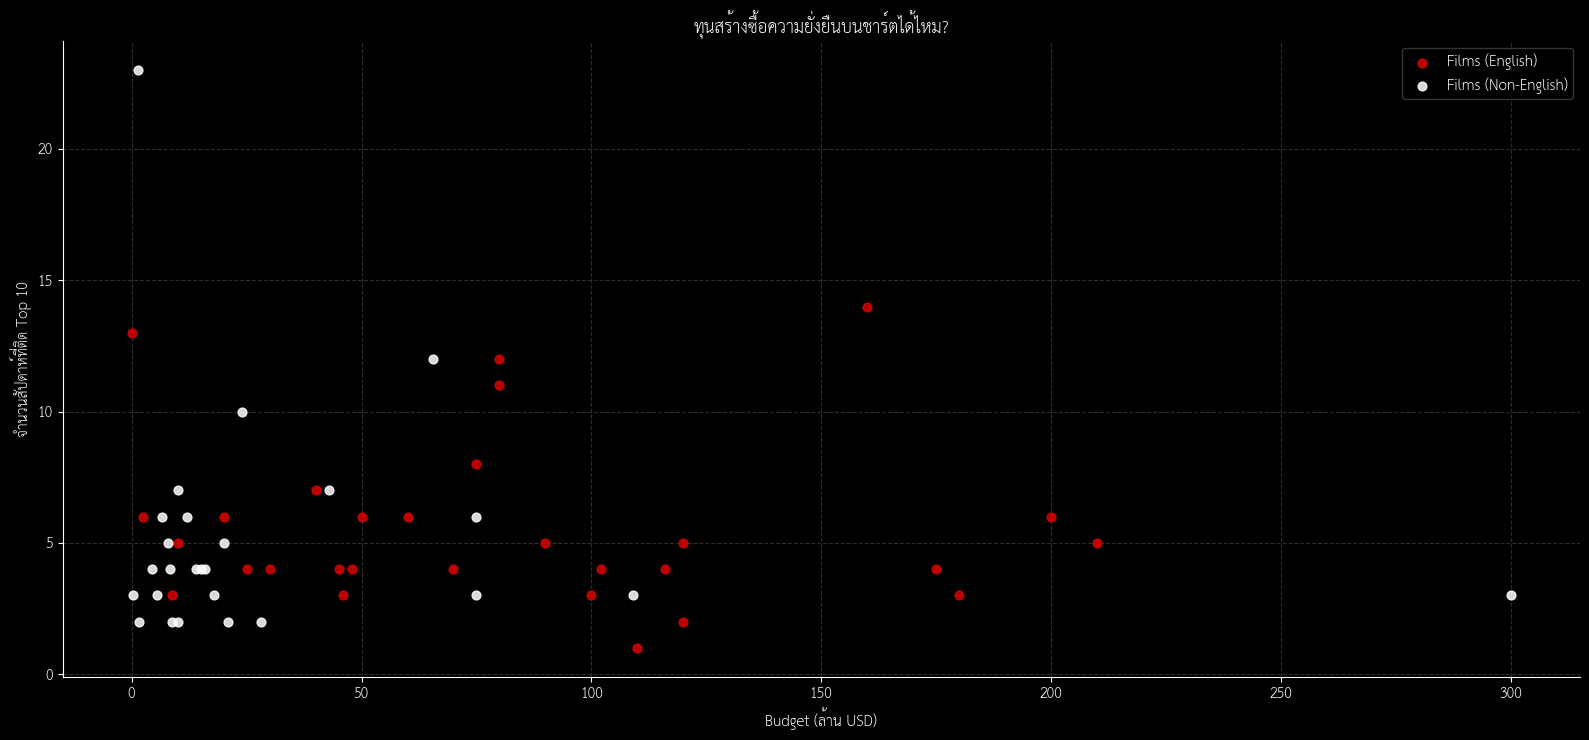

In [26]:
print("\n--- Box Office vs Total Views (เฉพาะกลุ่มเจ๊ง) ---")
# ปรับขนาดภาพเป็น (16, 7.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
fig.patch.set_facecolor('#000000')
text_color = "#ffffff"
line_color = "#404040"
color_box_office = "#564d4d"  # กราฟแท่ง Box Office
color_views = "#db0000"       # กราฟเส้น Total Views

for ax, s in zip(axes, segments):
    ax.set_facecolor('#000000')
    d = seg_df[s]
    flops = d[d["is_flop"]].sort_values("total_views", ascending=False).head(10)
    x = np.arange(len(flops))

    # 1. Bar Chart: Box Office (แกน Y ฝั่งซ้าย)
    bars = ax.bar(x, flops["Box_Office_USD"] / 1e6, width=0.4,
                  label="Box Office (ล้าน USD)", color=color_box_office, zorder=3)

    # 2. Line Chart: Total Views (แกน Y ฝั่งขวา)
    ax2 = ax.twinx()
    lines = ax2.plot(x, flops["total_views"] / 1e6, color=color_views,
                     marker='o', linewidth=2, label="Total Views (ล้าน)", zorder=4)

    # ตั้งค่าแกน X
    ax.set_xticks(x)
    ax.set_xticklabels(flops["show_title"], rotation=75, ha="right", fontsize=8, color=text_color)
    ax.set_title(s, color=text_color)

    # ตั้งค่า Grid และ Spines
    ax.grid(axis='y', color=line_color, linestyle='--', zorder=0, alpha=0.7)
    ax2.grid(False)

    for spine in ax.spines.values():
        spine.set_color(text_color)
    for spine in ax2.spines.values():
        spine.set_color(text_color)

    # ตั้งค่าสีข้อความและ Tick ให้ตรงตามแกน
    ax.set_ylabel("Box Office (ล้าน USD)", color=text_color)
    ax2.set_ylabel("Total Views (ล้าน)", color=color_views)
    ax.tick_params(colors=text_color)
    ax2.tick_params(axis='y', colors=color_views)

    # รวม Legend จากทั้ง 2 แกน
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, facecolor='#000000', edgecolor=line_color, labelcolor=text_color, loc='upper right')

fig.suptitle("หนังเจ๊งในโรง แต่ยอดวิว Netflix สูงสุด", color=text_color, y=1.02)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/act2_boxoffice_vs_views_by_segment.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)


# --- Scatter Plot (กรองเอา KPop Demon Hunters ออก) ---
print("\n--- ทุนสร้างซื้อความยั่งยืนบนชาร์ตได้ไหม? ---")
fig, ax = plt.subplots(figsize=(16, 7.5))
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')
scatter_colors = ["#db0000", "#ffffff"]

for i, s in enumerate(segments):
    d = seg_df[s]
    # กรองเอาภาพยนตร์ชื่อ "KPop Demon Hunters" ออก
    d = d[d["show_title"] != "KPop Demon Hunters"]

    c = scatter_colors[i % len(scatter_colors)]
    ax.scatter(d["Budget_USD"] / 1e6, d["total_weeks_in_top10"],
               label=s, color=c, alpha=0.85, s=40, zorder=3)

ax.set_xlabel("Budget (ล้าน USD)", color=text_color)
ax.set_ylabel("จำนวนสัปดาห์ที่ติด Top 10", color=text_color)
ax.set_title("ทุนสร้างซื้อความยั่งยืนบนชาร์ตได้ไหม?", color=text_color)
ax.grid(color=line_color, linestyle='--', zorder=0, alpha=0.7)
ax.spines["bottom"].set_color(text_color)
ax.spines["left"].set_color(text_color)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors=text_color)
ax.legend(facecolor='#000000', edgecolor=line_color, labelcolor=text_color)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/act2_budget_vs_weeks_by_segment.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)


--- ภาพรวมต่อ segment (n, flop_rate, avg views, avg weeks, avg imdb) ---
                      n  flop_rate  avg_total_views  avg_weeks_top10  \
category                                                               
Films (English)      30       0.37      52862267.37             7.47   
Films (Non-English)  26       0.31      12321479.80             5.19   

                     avg_imdb_rating  
category                              
Films (English)                 6.47  
Films (Non-English)             6.70  


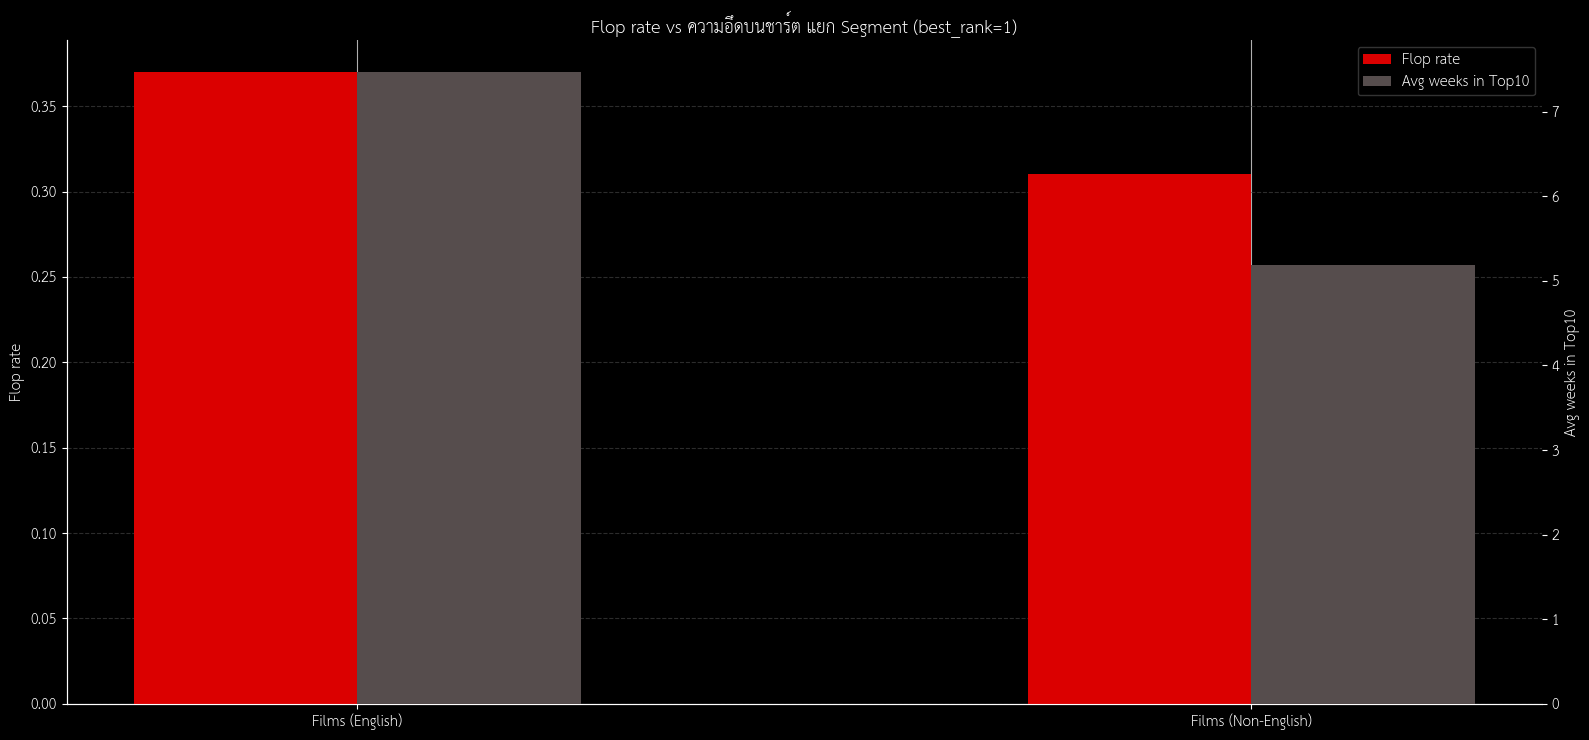

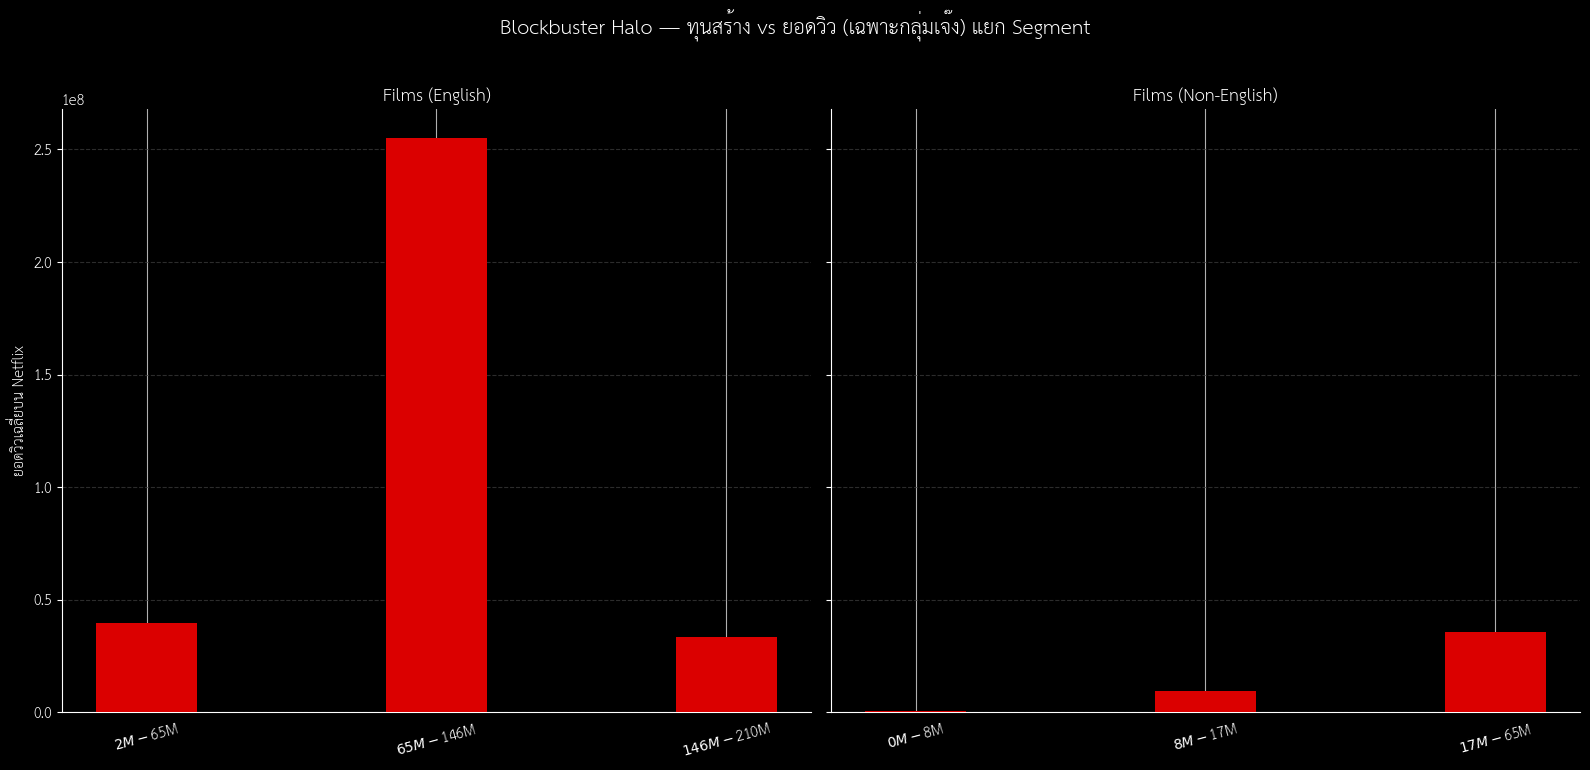

<Figure size 900x500 with 0 Axes>

In [27]:
print("\n--- ภาพรวมต่อ segment (n, flop_rate, avg views, avg weeks, avg imdb) ---")
cat_summary = df.groupby("category").agg(
    n=("show_title", "count"),
    flop_rate=("is_flop", "mean"),
    avg_total_views=("total_views", "mean"),
    avg_weeks_top10=("total_weeks_in_top10", "mean"),
    avg_imdb_rating=("imdb_rating", "mean"),
).round(2)
print(cat_summary)

# ปรับขนาดภาพเป็น (16, 7.5) ให้เท่ากันกับกราฟอื่น ๆ
fig, ax = plt.subplots(figsize=(16, 7.5))
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')
text_color = "#ffffff"
line_color = "#404040"

metrics = ["flop_rate", "avg_weeks_top10"]
x = np.arange(len(segments))
width = 0.25

bars1 = ax.bar(x - width / 2, cat_summary.loc[segments, "flop_rate"], width, label="Flop rate", color="#db0000", zorder=3)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width / 2, cat_summary.loc[segments, "avg_weeks_top10"], width, label="Avg weeks in Top10", color="#564d4d", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(segments, color=text_color)
ax.set_ylabel("Flop rate", color=text_color)
ax2.set_ylabel("Avg weeks in Top10", color=text_color)
ax.set_title("Flop rate vs ความอึดบนชาร์ต แยก Segment (best_rank=1)", color=text_color)
ax.grid(axis='y', color=line_color, linestyle='--', zorder=0, alpha=0.7)
ax2.grid(False)

for ax_obj in [ax, ax2]:
    ax_obj.spines["bottom"].set_color(text_color)
    ax_obj.spines["left"].set_color(text_color)
    ax_obj.spines["top"].set_visible(False)
    ax_obj.spines["right"].set_visible(False)
    ax_obj.tick_params(colors=text_color)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, facecolor='#000000', edgecolor=line_color, labelcolor=text_color, loc="upper right")

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/act3_overview_by_segment.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)

# ปรับขนาดภาพเป็น (16, 7.5) ให้เท่ากันกับกราฟอื่น ๆ
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True)
fig.patch.set_facecolor('#000000')
segment_colors = {"English": "#db0000", "Non-English": "#ffffff"}

for ax, s in zip(axes, segments):
    ax.set_facecolor('#000000')
    d = seg_df[s]
    flops = d[d["is_flop"]].copy()

    if len(flops) >= 3:
        budget_bins = pd.qcut(flops["Budget_USD"], q=3, duplicates="drop")
        formatted_labels = [f"${int(interval.left/1e6)}M - ${int(interval.right/1e6)}M" for interval in budget_bins.cat.categories]
        flops["budget_tier"] = budget_bins.cat.rename_categories(formatted_labels)
        halo = flops.groupby("budget_tier", observed=True)["total_views"].mean()
        x_pos = np.arange(len(halo))
        ax.bar(x_pos, halo.values, width=0.35, color=segment_colors.get(s, "#db0000"), zorder=3)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(halo.index, rotation=15, ha="center", fontsize=10, color=text_color)
    else:
        ax.text(0.5, 0.5, "ข้อมูลไม่พอ\n(เจ๊งน้อยกว่า 3 เรื่อง)", ha="center", va="center", color=text_color)
        ax.set_xticks([])

    ax.set_title(s, color=text_color)
    ax.grid(axis='y', color=line_color, linestyle='--', zorder=0, alpha=0.7)
    ax.spines["bottom"].set_color(text_color)
    ax.spines["left"].set_color(text_color)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='y', colors=text_color)

axes[0].set_ylabel("ยอดวิวเฉลี่ยบน Netflix", color=text_color)
fig.suptitle("Blockbuster Halo — ทุนสร้าง vs ยอดวิว (เฉพาะกลุ่มเจ๊ง) แยก Segment", color=text_color, fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/act3_blockbuster_halo_by_segment.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)
plt.savefig('filename.png', bbox_inches='tight', dpi=300)



--- Correlation IMDb Rating vs Total Views แยกตามสถานะเจ๊ง/ไม่เจ๊ง ---
  หนังเจ๊ง (18 เรื่อง): corr = 0.386, avg_rating = 6.6
  หนังไม่เจ๊ง (37 เรื่อง): corr = -0.040, avg_rating = 6.6


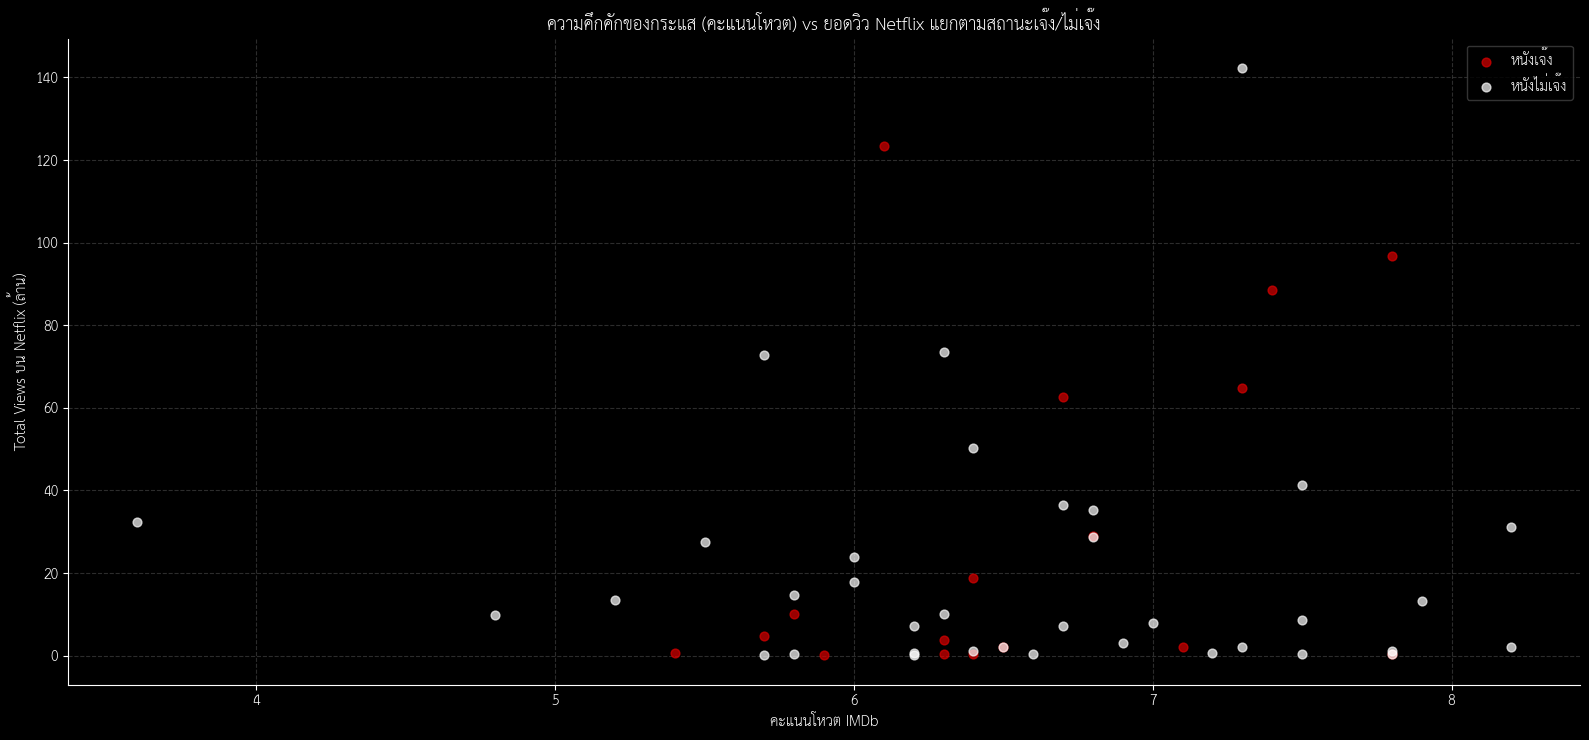

In [28]:
import matplotlib.pyplot as plt

# กรองเอาภาพยนตร์ชื่อ "KPop Demon Hunters" ออกจากชุดข้อมูล
df_filtered = df[df["show_title"] != "KPop Demon Hunters"].copy()

print("\n--- Correlation IMDb Rating vs Total Views แยกตามสถานะเจ๊ง/ไม่เจ๊ง ---")

flop_categories = [True, False]
flop_labels = {True: "เจ๊ง", False: "ไม่เจ๊ง"}
flop_colors = {True: "#db0000", False: "#ffffff"}

for is_flop_status in flop_categories:
    d = df_filtered[df_filtered["is_flop"] == is_flop_status]
    if len(d) > 1:
        c = d["imdb_rating"].corr(d["total_views"])
        print(f"  หนัง{flop_labels[is_flop_status]} ({len(d)} เรื่อง): corr = {c:.3f}, avg_rating = {d['imdb_rating'].mean():.1f}")
    else:
        print(f"  หนัง{flop_labels[is_flop_status]} ({len(d)} เรื่อง): Not enough data for correlation (requires >1 movie)")

# สร้างกราฟ (ใช้ข้อมูลจาก df_filtered ที่กรองออกแล้ว)
fig, ax = plt.subplots(figsize=(16, 7.5))
for is_flop_status in flop_categories:
    d = df_filtered[df_filtered["is_flop"] == is_flop_status]
    ax.scatter(d["imdb_rating"], d["total_views"] / 1e6,
               label=f"หนัง{flop_labels[is_flop_status]}",
               color=flop_colors[is_flop_status], alpha=0.7, s=40, zorder=3)

ax.set_xlabel("คะแนนโหวต IMDb")
ax.set_ylabel("Total Views บน Netflix (ล้าน)")
ax.set_title("ความคึกคักของกระแส (คะแนนโหวต) vs ยอดวิว Netflix แยกตามสถานะเจ๊ง/ไม่เจ๊ง")
ax.legend()

# ธีมสี Dark Mode
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')
ax.tick_params(colors="#ffffff")
ax.spines["bottom"].set_color("#ffffff")
ax.spines["left"].set_color("#ffffff")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.label.set_color("#ffffff")
ax.yaxis.label.set_color("#ffffff")
ax.title.set_color("#ffffff")
ax.legend(facecolor='#000000', edgecolor='#404040', labelcolor='#ffffff')

ax.grid(color='#404040', alpha=0.7, linestyle='--', linewidth=0.8, zorder=0)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/act4_rating_vs_views_by_flop_status.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)


--- Act 4: Correlation IMDb Rating vs Weeks in Top 10 แยกตามสถานะเจ๊ง/ไม่เจ๊ง ---
  หนังเจ๊ง (19 เรื่อง): corr = 0.299, avg_rating = 6.6
  หนังไม่เจ๊ง (37 เรื่อง): corr = 0.376, avg_rating = 6.6


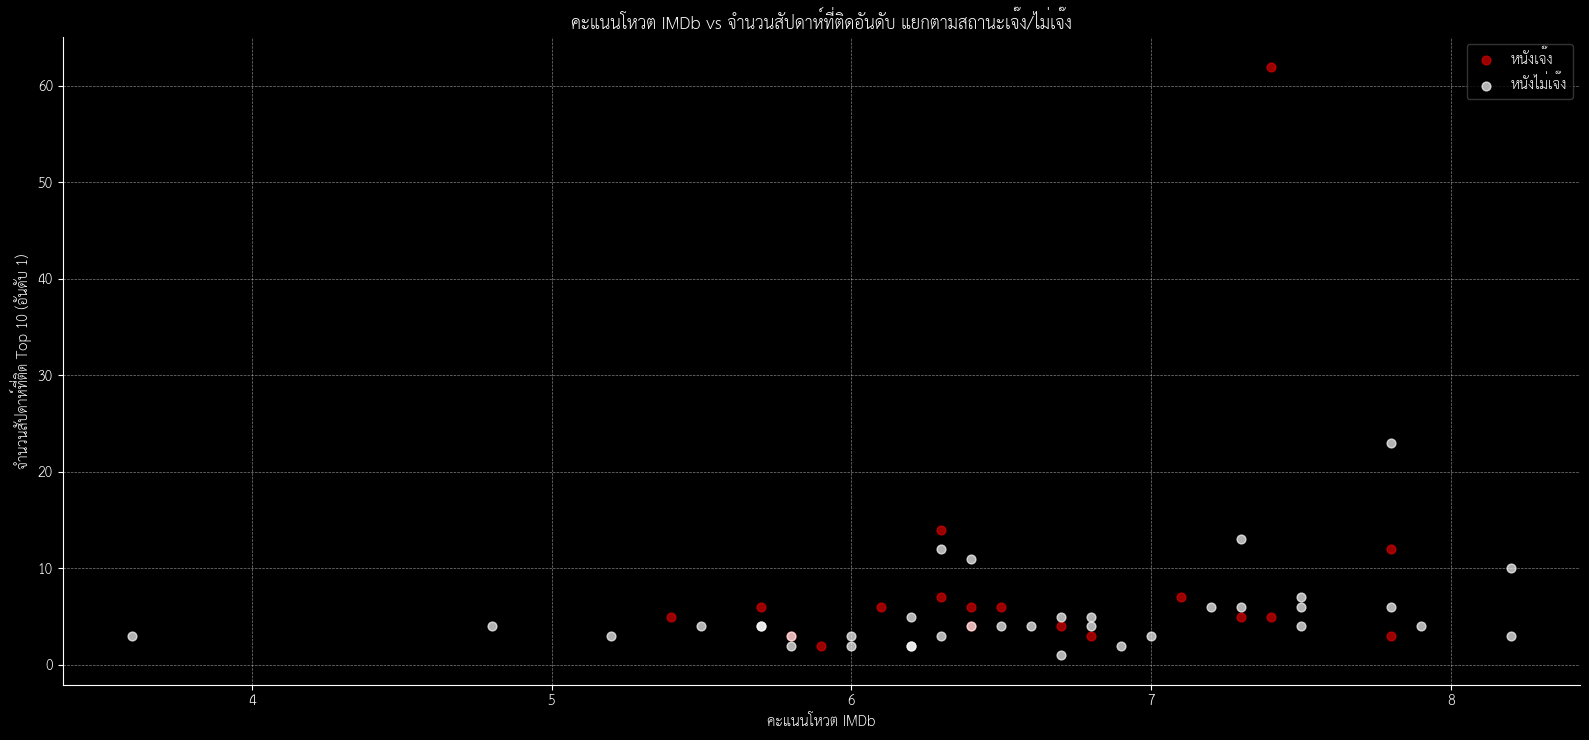

In [29]:
print("\n--- Act 4: Correlation IMDb Rating vs Weeks in Top 10 แยกตามสถานะเจ๊ง/ไม่เจ๊ง ---")

flop_categories = [True, False]
flop_labels = {True: "เจ๊ง", False: "ไม่เจ๊ง"}
flop_colors = {True: "#db0000", False: "#ffffff"}

for is_flop_status in flop_categories:
    d = df[df["is_flop"] == is_flop_status]
    if len(d) > 1:
        c = d["imdb_rating"].corr(d["total_weeks_in_top10"])
        print(f"  หนัง{flop_labels[is_flop_status]} ({len(d)} เรื่อง): corr = {c:.3f}, avg_rating = {d['imdb_rating'].mean():.1f}")
    else:
        print(f"  หนัง{flop_labels[is_flop_status]} ({len(d)} เรื่อง): Not enough data for correlation (requires >1 movie)")

# ปรับขนาดภาพเป็น (16, 7.5) ให้เท่ากันกับกราฟอื่น ๆ
fig, ax = plt.subplots(figsize=(16, 7.5))
for is_flop_status in flop_categories:
    d = df[df["is_flop"] == is_flop_status]
    ax.scatter(d["imdb_rating"], d["total_weeks_in_top10"],
               label=f"หนัง{flop_labels[is_flop_status]}",
               color=flop_colors[is_flop_status], alpha=0.7, s=40)

ax.set_xlabel("คะแนนโหวต IMDb")
ax.set_ylabel("จำนวนสัปดาห์ที่ติด Top 10 (อันดับ 1)")
ax.set_title("คะแนนโหวต IMDb vs จำนวนสัปดาห์ที่ติดอันดับ แยกตามสถานะเจ๊ง/ไม่เจ๊ง")
ax.legend()

fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')
ax.tick_params(colors="#ffffff")
ax.spines["bottom"].set_color("#ffffff")
ax.spines["left"].set_color("#ffffff")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.label.set_color("#ffffff")
ax.yaxis.label.set_color("#ffffff")
ax.title.set_color("#ffffff")
ax.legend(facecolor='#000000', edgecolor='#404040', labelcolor='#ffffff')

# เพิ่มเส้นตารางสีขาวที่โปร่งแสง 50%
ax.grid(color='#ffffff', alpha=0.5, linestyle='--', linewidth=0.5)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/act4_rating_vs_weeks_by_flop_status.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)


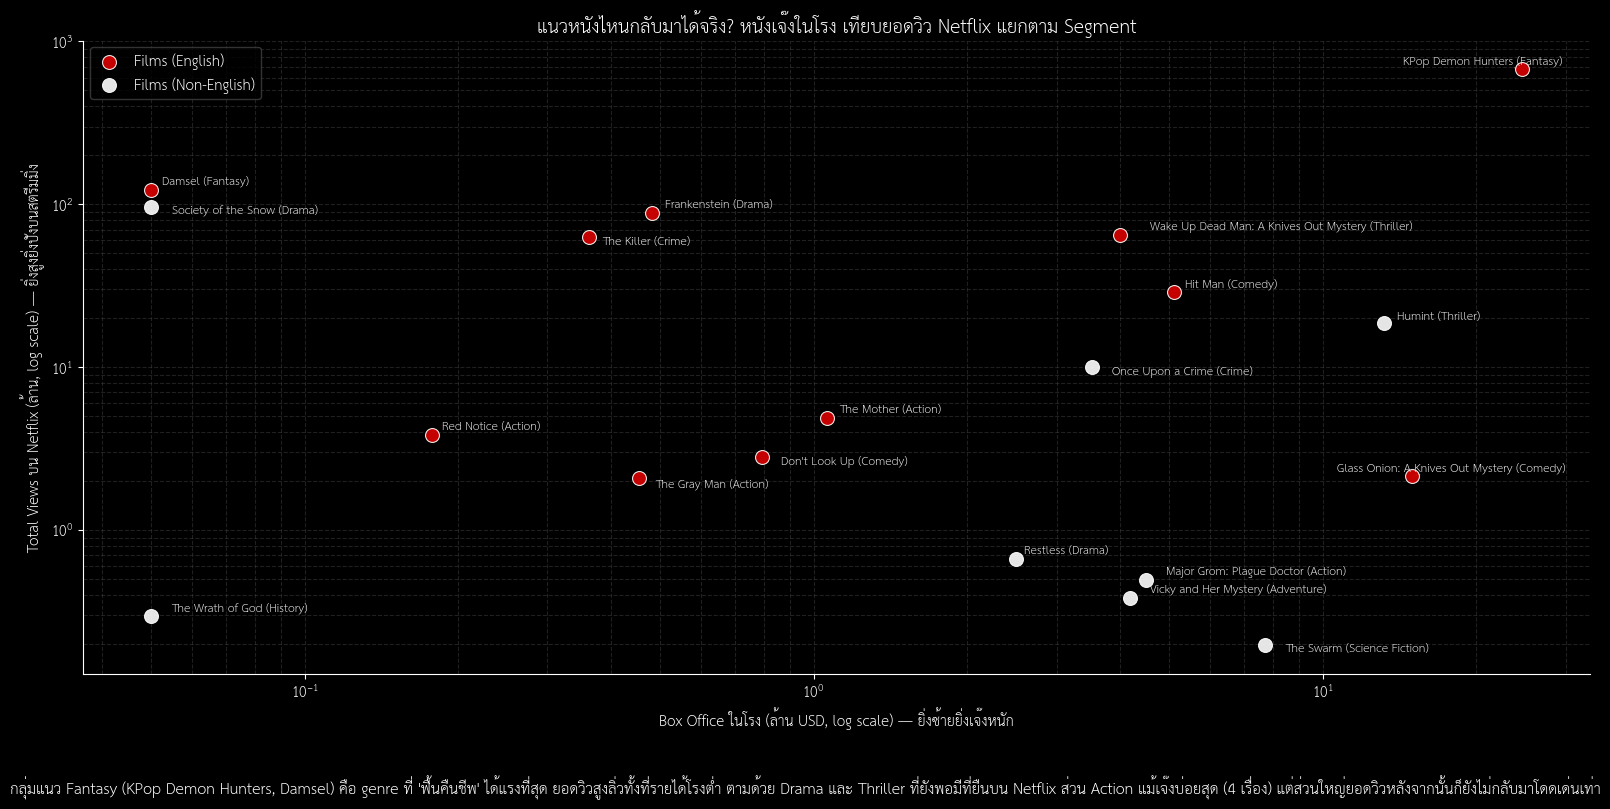

In [30]:
# Install adjustText if not already installed
!pip install adjustText --quiet

flops = df[df["is_flop"]].copy()
# แกน log ใช้ค่า 0 ไม่ได้ เลยดันค่าที่เป็น 0 ขึ้นเล็กน้อย (เฉพาะเพื่อพล็อต ไม่กระทบข้อมูลจริง)
flops["box_office_plot"] = (flops["Box_Office_USD"] / 1e6).clip(lower=0.05)
speaking_segments = ["Films (English)", "Films (Non-English)"]

# กำหนดสีตามธีม Dark Mode (English = #db0000, Non-English = #ffffff)
DARK_SEG_COLORS = {"Films (English)": "#db0000", "Films (Non-English)": "#ffffff"}

# Import adjustText to prevent label overlaps
from adjustText import adjust_text

# ------------------------------------------------------------------
# กราฟสรุปปิดท้าย: Box Office vs Total Views เฉพาะกลุ่มเจ๊ง (log scale ทั้งสองแกน)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 7.5))

# 1. ตั้งค่าสีพื้นหลังเป็นสีดำ #000000
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')

text_color = "#ffffff"
line_color = "#404040"

for s in speaking_segments:
    d = flops[flops["category"] == s]
    ax.scatter(d["box_office_plot"], d["total_views"] / 1e6,
               color=DARK_SEG_COLORS.get(s, "#db0000"), s=100, alpha=0.9,
               edgecolors="white", linewidth=0.8, label=s, zorder=3)

ax.set_xscale("log")
ax.set_yscale("log")

texts = []
for _, row in flops.iterrows():
    label = f"{row['show_title']} ({row['genres']})"
    # 2. ปรับสีตัวหนังสือป้ายชื่อหนังให้เป็นสีขาว (หรือเทาอ่อน) บนพื้นดำ
    t = ax.text(row["box_office_plot"], row["total_views"] / 1e6, label,
                fontsize=8, color="#e5e5e5")
    texts.append(t)

# 3. ปรับสีเส้นโยง (arrow) ให้สว่างขึ้นเล็กน้อยเพื่อให้มองเห็นบนพื้นดำ
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle="-", color="#888888", lw=0.6))

ax.set_xlabel("Box Office ในโรง (ล้าน USD, log scale) — ยิ่งซ้ายยิ่งเจ๊งหนัก", color=text_color)
ax.set_ylabel("Total Views บน Netflix (ล้าน, log scale) — ยิ่งสูงยิ่งปังบนสตรีมมิ่ง", color=text_color)
ax.set_title("แนวหนังไหนกลับมาได้จริง? หนังเจ๊งในโรง เทียบยอดวิว Netflix แยกตาม Segment",
             fontsize=13, color=text_color)

# ปิดกรอบด้านบนและขวา
ax.spines[["top", "right"]].set_visible(False)
ax.spines["bottom"].set_color(text_color)
ax.spines["left"].set_color(text_color)
ax.tick_params(colors=text_color)

# ปรับแต่ง Legend
legend = ax.legend(loc="upper left", frameon=True)
legend.get_frame().set_facecolor('#000000')
legend.get_frame().set_edgecolor(line_color)
for text in legend.get_texts():
    text.set_color(text_color)

# 4. ปรับสีเส้นกริดด้านในให้กลมกลืน
ax.grid(True, which="both", color=line_color, alpha=0.5, linestyle="--")

caption_text = ("กลุ่มแนว Fantasy (KPop Demon Hunters, Damsel) คือ genre ที่ 'ฟื้นคืนชีพ' ได้แรงที่สุด "
                "ยอดวิวสูงลิ่วทั้งที่รายได้โรงต่ำ ตามด้วย Drama และ Thriller ที่ยังพอมีที่ยืนบน Netflix "
                "ส่วน Action แม้เจ๊งบ่อยสุด (4 เรื่อง) แต่ส่วนใหญ่ยอดวิวหลังจากนั้นก็ยังไม่กลับมาโดดเด่นเท่า")

# ปรับสี Caption ด้านล่างกราฟให้เป็นสีขาว
fig.text(0.5, -0.04, caption_text, ha="center", va="top", wrap=True,
         fontsize=10.5, color=text_color)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/summary_genre_resurrection_scatter.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)



--- Films (English) ---
     genres  n  avg_boxoffice     avg_views
4   Fantasy  2   1.231248e+07  3.986500e+08
3     Drama  1   4.806780e+05  8.850000e+07
5  Thriller  1   4.000000e+06  6.470000e+07
2     Crime  1   3.621130e+05  6.260000e+07
1    Comedy  3   6.964512e+06  1.129275e+07
0    Action  3   5.648063e+05  3.597317e+06

--- Films (Non-English) ---
            genres  n  avg_boxoffice     avg_views
3            Drama  2      1250640.5  4.873198e+07
6         Thriller  1     13207600.0  1.870000e+07
2            Crime  1      3520427.0  1.010000e+07
0           Action  1      4493306.0  4.911029e+05
1        Adventure  1      4181043.0  3.855952e+05
4          History  1        37041.0  2.978947e+05
5  Science Fiction  1      7700000.0  1.969828e+05


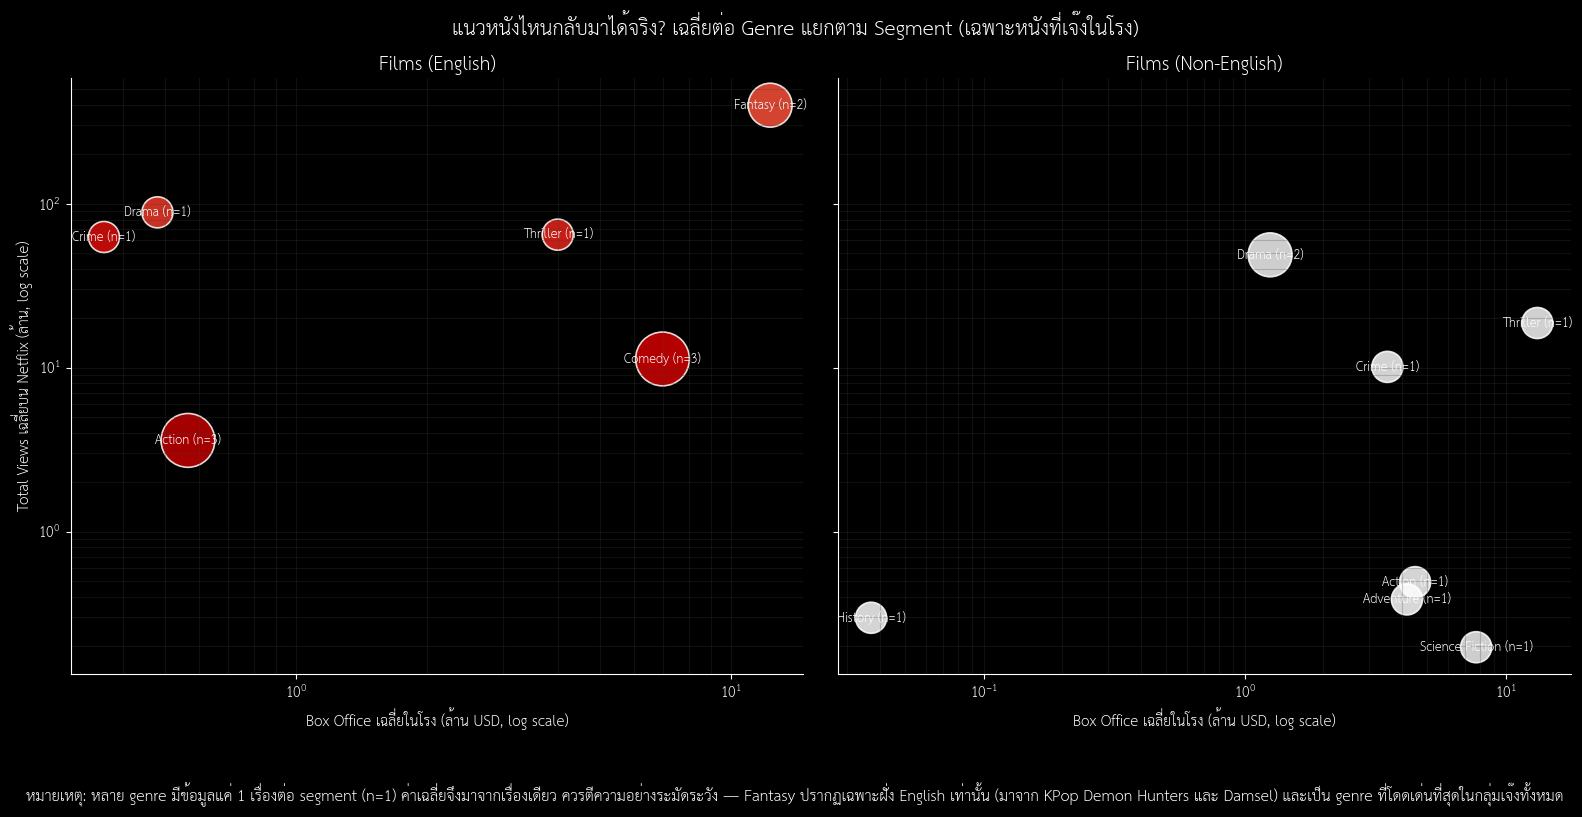


บันทึกกราฟแล้ว: summary_genre_grouped_by_segment.png


In [31]:
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

# Define common text and line colors for dark theme consistency
text_color = "#ffffff"
line_color = "#404040"

# Assuming DARK_SEG_COLORS is defined globally or from previous cells.
# From kernel state, DARK_SEG_COLORS = {'Films (English)': '#db0000', 'Films (Non-English)': '#ffffff'}
# Create custom colormaps for each segment based on DARK_SEG_COLORS
SEG_CMAPS = {}
for segment, base_color in DARK_SEG_COLORS.items():
    if segment == "Films (English)":
        # Red shades
        colors_list = ["#8B0000", base_color, "#FF6347"] # Dark Red, Base Red, Tomato
    elif segment == "Films (Non-English)":
        # White/Grey shades
        colors_list = ["#D3D3D3", base_color, "#F0F0F0"] # Light Gray, White, Lighter Gray
    else:
        # Generic Fallback if more segments are added
        colors_list = ["#505050", base_color, "#E0E0E0"]

    cmap = LinearSegmentedColormap.from_list(f"{segment.replace(' ', '_').replace('(', '').replace(')', '')}_cmap", colors_list)
    SEG_CMAPS[segment] = cmap

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True)

# Set main figure background to black
fig.patch.set_facecolor('#000000')

for ax, s in zip(axes, segments):
    ax.set_facecolor('#000000') # Set subplot background to black
    d = flops[flops["category"] == s]
    genre_summary = d.groupby("genres").agg(
        n=("show_title", "count"),
        avg_boxoffice=("Box_Office_USD", "mean"),
        avg_views=("total_views", "mean"),
    ).reset_index().sort_values("avg_views", ascending=False)

    print(f"\n--- {s} ---")
    print(genre_summary)

    x = genre_summary["avg_boxoffice"].clip(lower=0.02e6) / 1e6
    y = genre_summary["avg_views"] / 1e6
    sizes = genre_summary["n"] * 500
    colors = SEG_CMAPS[s](np.linspace(0.9, 0.35, len(genre_summary)))

    ax.scatter(x, y, s=sizes, color=colors, alpha=0.85, edgecolors="white", linewidth=1.2)

    for i, row in genre_summary.reset_index(drop=True).iterrows():
        ax.annotate(f"{row['genres']} (n={row['n']})",
                    (x.iloc[i], y.iloc[i]),
                    ha="center", va="center", fontsize=8.5, color=text_color, fontweight="bold") # Changed color to text_color

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Box Office เฉลี่ยในโรง (ล้าน USD, log scale)", color=text_color)
    ax.set_title(s, fontsize=13, color=text_color) # Changed color to text_color
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["bottom"].set_color(text_color) # Added for dark theme
    ax.spines["left"].set_color(text_color) # Added for dark theme
    ax.tick_params(colors=text_color) # Changed colors to text_color
    ax.grid(True, which="both", color=line_color, alpha=0.25) # Changed grid color to line_color

axes[0].set_ylabel("Total Views เฉลี่ยบน Netflix (ล้าน, log scale)", color=text_color)
fig.suptitle("แนวหนังไหนกลับมาได้จริง? เฉลี่ยต่อ Genre แยกตาม Segment (เฉพาะหนังที่เจ๊งในโรง)",
             fontsize=14, color=text_color) # Changed color to text_color

caption_text = ("หมายเหตุ: หลาย genre มีข้อมูลแค่ 1 เรื่องต่อ segment (n=1) ค่าเฉลี่ยจึงมาจากเรื่องเดียว "
                 "ควรตีความอย่างระมัดระวัง — Fantasy ปรากฏเฉพาะฝั่ง English เท่านั้น (มาจาก KPop Demon Hunters "
                 "และ Damsel) และเป็น genre ที่โดดเด่นที่สุดในกลุ่มเจ๊งทั้งหมด")

fig.text(0.5, -0.05, caption_text, ha="center", va="top", wrap=True,
         fontsize=10.5, color=text_color) # Changed color to text_color

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/summary_genre_grouped_by_segment.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)

print("\nบันทึกกราฟแล้ว: summary_genre_grouped_by_segment.png")

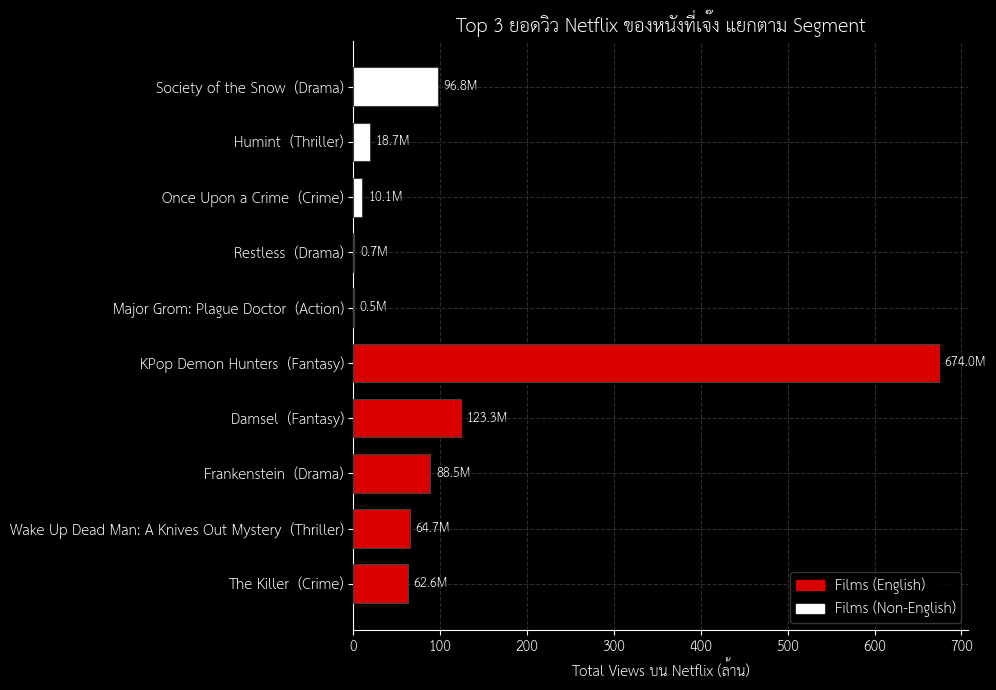

บันทึกกราฟแล้ว: summary_views_top3_by_segment.png

Top 3 ของแต่ละ Segment:
           category                             show_title   genres  total_views  profit_loss_usd
    Films (English)                             The Killer    Crime 6.260000e+07       -174637887
    Films (English) Wake Up Dead Man: A Knives Out Mystery Thriller 6.470000e+07       -206000000
    Films (English)                           Frankenstein    Drama 8.850000e+07       -119519322
    Films (English)                                 Damsel  Fantasy 1.233000e+08        -59995000
    Films (English)                     KPop Demon Hunters  Fantasy 6.740000e+08        -75380047
Films (Non-English)              Major Grom: Plague Doctor   Action 4.911029e+05         -5506694
Films (Non-English)                               Restless    Drama 6.639560e+05         -5500000
Films (Non-English)                      Once Upon a Crime    Crime 1.010000e+07        -14479573
Films (Non-English)                        

In [32]:
import matplotlib.pyplot as plt

# Ensure 'profit_loss_usd' and 'is_flop' columns are present in df
df["profit_loss_usd"] = df["Box_Office_USD"] - df["Budget_USD"]
df["is_flop"] = df["profit_loss_usd"] < 0

flops = df[df["is_flop"]].copy()

top3 = (
    flops
    .sort_values(["category", "total_views"], ascending=[True, False])
    .groupby("category", group_keys=False)
    .head(5)
    .sort_values(["category", "total_views"], ascending=[True, True])
)

# ------------------------------------------------------------------
# สร้าง Label
# ------------------------------------------------------------------
labels = [
    f"{t}  ({g})"
    for t, g in zip(top3["show_title"], top3["genres"])
]

# กำหนดสีตามธีม Dark Mode (English = #db0000, Non-English = #ffffff)
DARK_SEG_COLORS = {"Films (English)": "#db0000", "Films (Non-English)": "#ffffff"}

# แมปสีให้ตรงกับ category ของแต่ละเรื่อง (ถ้าชื่อ category ใน df ต่างออกไป สามารถปรับ key ได้ครับ)
colors = [
    DARK_SEG_COLORS.get(c, "#db0000")
    for c in top3["category"]
]

# ------------------------------------------------------------------
# กราฟ
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

# Set figure and axes background to black
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')

bars = ax.barh(
    labels,
    top3["total_views"] / 1e6,
    color=colors,
    edgecolor="#404040",
    linewidth=0.8,
    height=0.7,
    zorder=3
)

# ------------------------------------------------------------------
# ใส่ตัวเลขยอดวิว
# ------------------------------------------------------------------
max_views = (top3["total_views"] / 1e6).max()

for bar, views in zip(bars, top3["total_views"] / 1e6):
    ax.text(
        bar.get_width() + max_views * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{views:,.1f}M",
        va="center",
        fontsize=9,
        color="#ffffff"
    )

# ------------------------------------------------------------------
# ตกแต่ง
# ------------------------------------------------------------------
ax.set_xlabel("Total Views บน Netflix (ล้าน)", color="#ffffff")

ax.set_title(
    "Top 3 ยอดวิว Netflix ของหนังที่เจ๊ง แยกตาม Segment",
    fontsize=13,
    color="#ffffff"
)

ax.spines[["top", "right"]].set_visible(False)
ax.spines["bottom"].set_color("#ffffff")
ax.spines["left"].set_color("#ffffff")
ax.tick_params(colors="#ffffff")
ax.grid(color="#404040", alpha=0.7, linestyle='--', zorder=0)

# สร้าง Handle สำหรับ Legend ตามธีมสีใหม่
handles = [
    plt.Rectangle((0, 0), 1, 1, color=col)
    for col in DARK_SEG_COLORS.values()
]

ax.legend(
    handles,
    DARK_SEG_COLORS.keys(),
    loc="lower right",
    frameon=True,
    facecolor='#000000',
    edgecolor='#404040',
    labelcolor='#ffffff'
)

fig.tight_layout()

# ------------------------------------------------------------------
# บันทึก
# ------------------------------------------------------------------
fig.savefig(
    f"{OUT_DIR}/summary_views_top3_by_segment.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()
plt.close(fig)

print("บันทึกกราฟแล้ว: summary_views_top3_by_segment.png")

# แสดงข้อมูล Top 3
print("\nTop 3 ของแต่ละ Segment:")
print(
    top3[
        ["category", "show_title", "genres", "total_views", "profit_loss_usd"]
    ].to_string(index=False)
)

In [33]:
from google.colab import files
import time
import os

# รายการภาพกราฟทั้งหมดที่สร้างขึ้นรวมถึงกราฟสรุปปิดท้าย
image_files = [
    "flop_count_grouped_by_segment.png",
    "genre_distribution_flops.png",
    "act1_budget_vs_boxoffice_by_segment.png",
    "act2_boxoffice_vs_views_by_segment.png",
    "act2_budget_vs_weeks_by_segment.png",
    "act3_overview_by_segment.png",
    "act3_blockbuster_halo_by_segment.png",
    "act4_rating_vs_views_by_flop_status.png",
    "act4_rating_vs_weeks_by_flop_status.png",
    "summary_genre_resurrection_scatter.png",
    "summary_genre_grouped_by_segment.png",
    "summary_views_top3_by_segment.png"
]

print("เริ่มทำการดาวน์โหลดกราฟผลลัพธ์ทั้งหมดตามลำดับ...")
for i, filename in enumerate(image_files, 1):
    try:
        # ตรวจสอบว่าไฟล์มีอยู่จริงและมีขนาดมากกว่า 0 ก่อนทำการดาวน์โหลด
        if os.path.exists(filename) and os.path.getsize(filename) > 0:
            print(f"[{i}/{len(image_files)}] กำลังดาวน์โหลด: {filename}")
            files.download(filename)
            # หน่วงเวลาเพื่อป้องกันไม่ให้เบราว์เซอร์บล็อกการดาวน์โหลดหลายไฟล์พร้อมกัน
            time.sleep(3)
        else:
            print(f"[{i}/{len(image_files)}] ข้ามการดาวน์โหลด: {filename} (ไฟล์ไม่สมบูรณ์หรือไม่มีอยู่)")
    except Exception as e:
        print(f"ไม่สามารถดาวน์โหลด {filename} ได้เนื่องจาก: {e}")

print("เสร็จสิ้นการดาวน์โหลด!")

เริ่มทำการดาวน์โหลดกราฟผลลัพธ์ทั้งหมดตามลำดับ...
[1/12] กำลังดาวน์โหลด: flop_count_grouped_by_segment.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[2/12] กำลังดาวน์โหลด: genre_distribution_flops.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

[12/12] กำลังดาวน์โหลด: summary_views_top3_by_segment.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

เสร็จสิ้นการดาวน์โหลด!


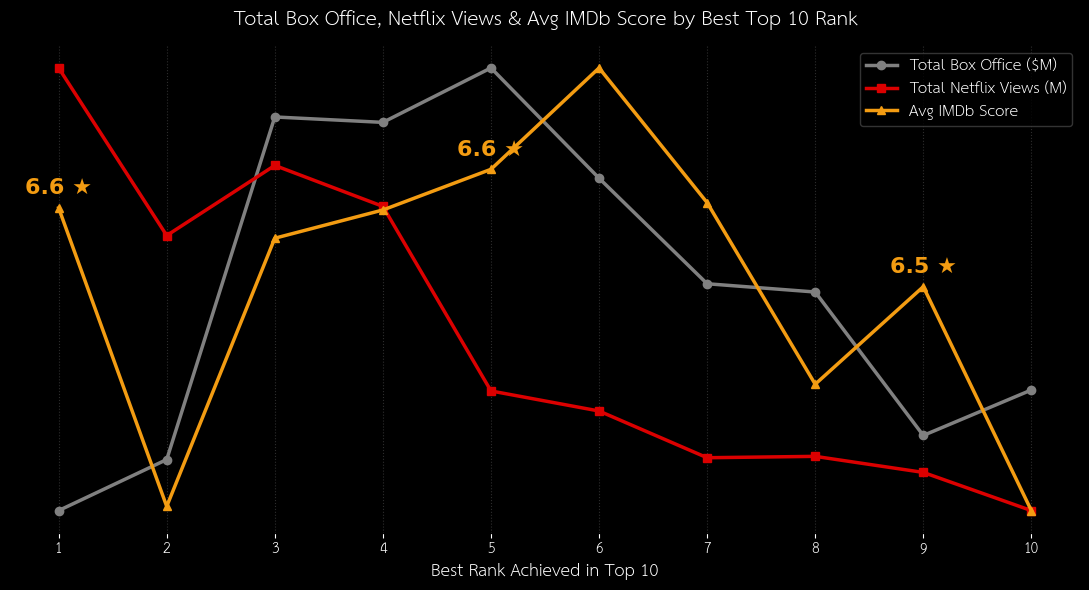

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# อ่านข้อมูลจากไฟล์ Excel
file_path = '/content/drive/MyDrive/netflix/Movie_Netfilx 1.xlsx'
df = pd.read_excel(file_path)

# ----------------------------------------------------
# 1. กรองเอา "K-pop Demon Hunters" ออกจากข้อมูล
# ----------------------------------------------------
movie_title_col = 'show_title'
df = df[~df[movie_title_col].astype(str).str.contains('K-pop Demon Hunters|Kpop Demon Hunters', case=False, na=False)]

# ----------------------------------------------------
# 2. จัดกลุ่มข้อมูล (Group By) ตามอันดับ
# ----------------------------------------------------
rank_col = 'best_rank'    # คอลัมน์อันดับ
imdb_col = 'imdb_rating'  # คอลัมน์คะแนน IMDb

df_grouped = df.groupby(rank_col).agg({
    'Box_Office_USD': 'sum',
    'total_views': 'sum',
    imdb_col: 'mean'
}).reset_index()

df_grouped = df_grouped.sort_values(by=rank_col)

# ----------------------------------------------------
# 3. สร้างกราฟเส้น (Line Chart - ธีม Dark Mode)
# ----------------------------------------------------
fig, ax1 = plt.subplots(figsize=(11, 6))

# ตั้งค่าสีพื้นหลังเป็นสีดำ #000000
fig.patch.set_facecolor('#000000')
ax1.set_facecolor('#000000')

text_color = "#ffffff"
line_color = "#404040"

# เส้น 1: Total Box Office (แกน Y1) - ใช้สีเทาอ่อน
line1 = ax1.plot(df_grouped[rank_col], df_grouped['Box_Office_USD'],
                 marker='o', linewidth=2.5, linestyle='-', color='#808080', label='Total Box Office ($M)')

# เส้น 2: Total Netflix Views (แกน Y2) - ใช้สีแดง #db0000
ax2 = ax1.twinx()
line2 = ax2.plot(df_grouped[rank_col], df_grouped['total_views'],
                 marker='s', linewidth=2.5, linestyle='-', color='#db0000', label='Total Netflix Views (M)')

# เส้น 3: Avg IMDb Score (แกน Y3) - ใช้สีทอง #f39c12
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 40))
line3 = ax3.plot(df_grouped[rank_col], df_grouped[imdb_col],
                 marker='^', linewidth=2.5, linestyle='-', color='#f39c12', label='Avg IMDb Score')

# ----------------------------------------------------
# 4. ปรับแต่งองค์ประกอบ
# ----------------------------------------------------
ax1.set_xticks(df_grouped[rank_col].unique())
ax1.set_xlabel('Best Rank Achieved in Top 10', fontsize=12, fontweight='bold', color=text_color)

# ปิดสเกลตัวเลขและป้ายชื่อของแกน Y ทั้งหมด
for ax in [ax1, ax2, ax3]:
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

# เปิดเฉพาะเส้นตารางแนวตั้ง (Vertical Gridlines) สีเทาเข้ม
ax1.xaxis.grid(True, linestyle=':', alpha=0.7, color=line_color)

# ปรับสี Ticks บนแกน X
ax1.tick_params(colors=text_color)

# ----------------------------------------------------
# 5. แสดงคะแนน IMDb เฉลี่ย พร้อมสัญลักษณ์ดาว (★) ที่อันดับ 1, 5, 9
# ----------------------------------------------------
target_ranks = [1, 5, 9]

for rank in target_ranks:
    if rank in df_grouped[rank_col].values:
        imdb_val = df_grouped[df_grouped[rank_col] == rank][imdb_col].values[0]
        # ใช้ family='DejaVu Sans' หรือ 'sans-serif' สำหรับจุดที่มีสัญลักษณ์พิเศษเพื่อไม่ให้รูปดาวหาย
        ax3.annotate(f'{imdb_val:.1f} ★',
                     (rank, imdb_val),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center',
                     color='#f39c12',
                     fontweight='bold',
                     fontfamily='DejaVu Sans',
                     fontsize=16)

# ----------------------------------------------------
# 6. ใส่คำอธิบายกำกับเส้น (Legend ธีมมืด)
# ----------------------------------------------------
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True,
           facecolor='#000000', edgecolor=line_color, labelcolor=text_color, fontsize=11)

plt.title('Total Box Office, Netflix Views & Avg IMDb Score by Best Top 10 Rank',
          fontsize=14, fontweight='bold', pad=15, color=text_color)

fig.tight_layout()
plt.savefig(f"{OUT_DIR}/rank_metrics_trend.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)

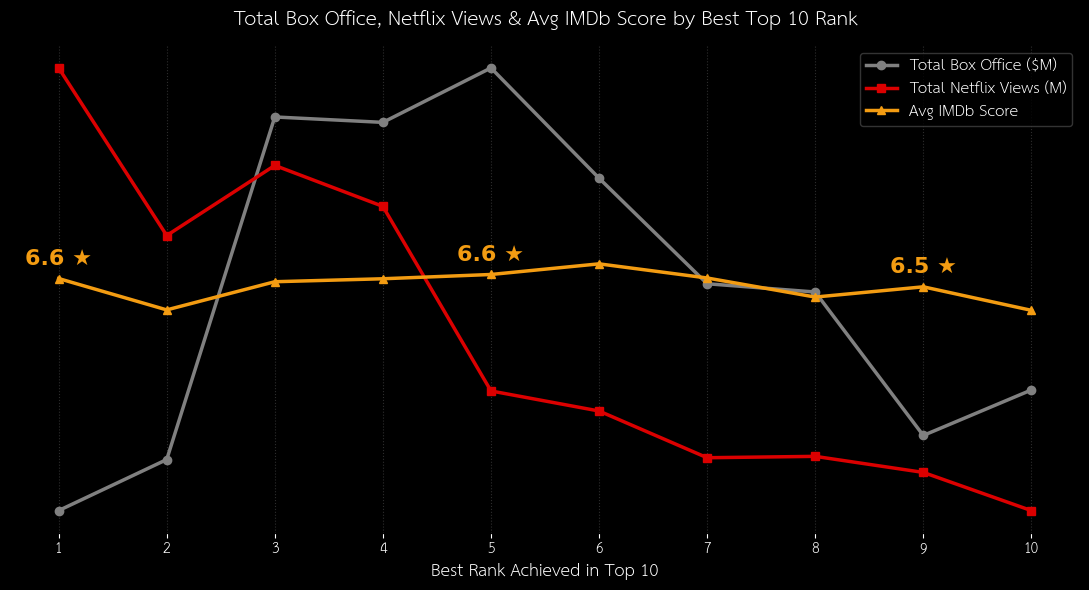

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# อ่านข้อมูลจากไฟล์ Excel
file_path = '/content/drive/MyDrive/netflix/Movie_Netfilx 1.xlsx'
df = pd.read_excel(file_path)

# ----------------------------------------------------
# 1. กรองเอา "K-pop Demon Hunters" ออกจากข้อมูล
# ----------------------------------------------------
movie_title_col = 'show_title'
df = df[~df[movie_title_col].astype(str).str.contains('K-pop Demon Hunters|Kpop Demon Hunters', case=False, na=False)]

# ----------------------------------------------------
# 2. จัดกลุ่มข้อมูล (Group By) ตามอันดับ
# ----------------------------------------------------
rank_col = 'best_rank'    # คอลัมน์อันดับ
imdb_col = 'imdb_rating'  # คอลัมน์คะแนน IMDb

df_grouped = df.groupby(rank_col).agg({
    'Box_Office_USD': 'sum',
    'total_views': 'sum',
    imdb_col: 'mean'
}).reset_index()

df_grouped = df_grouped.sort_values(by=rank_col)

# ----------------------------------------------------
# 3. สร้างกราฟเส้น (Line Chart - ธีม Dark Mode)
# ----------------------------------------------------
fig, ax1 = plt.subplots(figsize=(11, 6))

# ตั้งค่าสีพื้นหลังเป็นสีดำ #000000
fig.patch.set_facecolor('#000000')
ax1.set_facecolor('#000000')

text_color = "#ffffff"
line_color = "#404040"

# เส้น 1: Total Box Office (แกน Y1) - ใช้สีเทาอ่อน
line1 = ax1.plot(df_grouped[rank_col], df_grouped['Box_Office_USD'],
                 marker='o', linewidth=2.5, linestyle='-', color='#808080', label='Total Box Office ($M)')

# เส้น 2: Total Netflix Views (แกน Y2) - ใช้สีแดง #db0000
ax2 = ax1.twinx()
line2 = ax2.plot(df_grouped[rank_col], df_grouped['total_views'],
                 marker='s', linewidth=2.5, linestyle='-', color='#db0000', label='Total Netflix Views (M)')

# เส้น 3: Avg IMDb Score (แกน Y3) - ใช้สีทอง #f39c12
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 40))
line3 = ax3.plot(df_grouped[rank_col], df_grouped[imdb_col],
                 marker='^', linewidth=2.5, linestyle='-', color='#f39c12', label='Avg IMDb Score')

# ล็อคสเกลแกน Y ของคะแนน IMDb ให้อยู่ในช่วง 5 - 8
ax3.set_ylim(5, 8)

# ----------------------------------------------------
# 4. ปรับแต่งองค์ประกอบ
# ----------------------------------------------------
ax1.set_xticks(df_grouped[rank_col].unique())
ax1.set_xlabel('Best Rank Achieved in Top 10', fontsize=12, fontweight='bold', color=text_color)

# ปิดสเกลตัวเลขและป้ายชื่อของแกน Y ทั้งหมด
for ax in [ax1, ax2, ax3]:
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

# เปิดเฉพาะเส้นตารางแนวตั้ง (Vertical Gridlines) สีเทาเข้ม
ax1.xaxis.grid(True, linestyle=':', alpha=0.7, color=line_color)

# ปรับสี Ticks บนแกน X
ax1.tick_params(colors=text_color)

# ----------------------------------------------------
# 5. แสดงคะแนน IMDb เฉลี่ย พร้อมสัญลักษณ์ดาว (★) ที่อันดับ 1, 5, 9
# ----------------------------------------------------
target_ranks = [1, 5, 9]

for rank in target_ranks:
    if rank in df_grouped[rank_col].values:
        imdb_val = df_grouped[df_grouped[rank_col] == rank][imdb_col].values[0]
        ax3.annotate(f'{imdb_val:.1f} ★',
                     (rank, imdb_val),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center',
                     color='#f39c12',
                     fontweight='bold',
                     fontfamily='DejaVu Sans',
                     fontsize=16)

# ----------------------------------------------------
# 6. ใส่คำอธิบายกำกับเส้น (Legend ธีมมืด)
# ----------------------------------------------------
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True,
           facecolor='#000000', edgecolor=line_color, labelcolor=text_color, fontsize=11)

plt.title('Total Box Office, Netflix Views & Avg IMDb Score by Best Top 10 Rank',
          fontsize=14, fontweight='bold', pad=15, color=text_color)

fig.tight_layout()
plt.savefig(f"{OUT_DIR}/rank_metrics_trend.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close(fig)